# KAN Symbolic Health Equation Discovery for Gearbox Fault Detection

**Core idea:** A KAN autoencoder is trained on *healthy data only* (no fault labels). After training, the learned B-spline activations on each edge are extracted and fitted to explicit symbolic functions (linear, sigmoid, log, etc.) via BIC-optimal curve fitting. These compose into human-readable **health equations** — e.g. `z₃ ≈ +0.82·σ(S2_kurt) + 0.41·log|S1_rms| − 0.17`. Anomaly detection is then dual-scored:
- **Score A**: standard per-feature reconstruction MSE
- **Score B** *(novel)*: how badly the test point violates the symbolic health equations
- **Score C**: equal-weight combination of A and B

Unlike weight-norm feature importance, Score B produces an interpretable, per-equation fault attribution that can be validated against gearbox physics.

This pipeline deliberately avoids the TwoNN → bottleneck → feature-count argument from the companion notebook; the bottleneck size `B` is a tunable hyperparameter.

## Setup & Imports

In [1]:
# Strip conflicting user-level packages so conda env versions are used
import sys
sys.path = [p for p in sys.path if not p.startswith("/home/suleiman/.local/lib")]

#%pip install pandas numpy torch scikit-learn scipy matplotlib nbformat -q
import os, sys, glob, warnings
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from scipy.stats import skew, kurtosis
from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import roc_auc_score, pairwise_distances
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from IPython.display import display
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

BASE_DIR      = os.path.abspath(".")
DATASET_DIR   = os.path.join(BASE_DIR, "Gearbox Dataset")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
RESULTS_DIR   = os.path.join(BASE_DIR, "results_kan_symbolic")
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

WINDOWS      = [300, 400, 500, 600, 700, 800, 900, 1000]
SEED         = 42
B            = 8        # bottleneck size — fixed hyperparameter, NOT from TwoNN
LAMBDA_REG   = 1e-4     # spline L1 regularisation weight
PRUNE_ALPHA  = 0.05     # edges below PRUNE_ALPHA * max_norm are pruned
EPOCHS       = 150
ABL_EPOCHS   = 100      # reduced epochs for ablation variants
np.random.seed(SEED)
torch.manual_seed(SEED)

sys.path.insert(0, os.path.join(BASE_DIR, "efficient_kan"))
from efficient_kan import KAN

dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {dev}")
print(f"B={B}, lambda={LAMBDA_REG}, alpha={PRUNE_ALPHA}, epochs={EPOCHS}")


Device: cpu
B=8, lambda=0.0001, alpha=0.05, epochs=150


## 1) Feature Extraction (44 Features × 8 Window Sizes)

11 statistical features × 4 sensor channels (S1–S4). Files are cached in `data/processed/features_W{W}.csv`.

In [2]:
FEATURE_NAMES = ["mean", "rms", "std", "var", "skew", "kurtosis", "p2p",
                 "crest", "shape", "margin", "impulse"]
CHANNELS = ["S1", "S2", "S3", "S4"]

def compute_11_features(signal):
    rms_val = np.sqrt(np.mean(signal**2))
    margin_denom = np.mean(np.sqrt(np.abs(signal)))**2
    return [
        np.mean(signal), rms_val, np.std(signal), np.var(signal),
        skew(signal), kurtosis(signal), np.ptp(signal),
        np.max(np.abs(signal)) / rms_val if rms_val > 0 else 0,
        rms_val / np.mean(np.abs(signal)) if np.mean(np.abs(signal)) > 0 else 0,
        np.max(np.abs(signal)) / margin_denom if margin_denom > 0 else 0,
        np.max(np.abs(signal)) / np.mean(np.abs(signal)) if np.mean(np.abs(signal)) > 0 else 0,
    ]

def extract_features(W):
    all_data = []
    filepaths = glob.glob(os.path.join(DATASET_DIR, "**", "*.txt"), recursive=True)
    for filepath in filepaths:
        fname = os.path.basename(filepath).lower()
        if "healthy" in fname:   label = 0
        elif "broken" in fname:  label = 1
        else:                    continue
        load_val = 0
        for l in [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]:
            if f"{l}hz" in fname or f"{l}load" in fname:
                load_val = l
        try:
            df = pd.read_csv(filepath, sep='\t', header=None)
            if df.shape[1] < 4:
                df = pd.read_csv(filepath, sep=',', header=None)
            series = df.iloc[:, :4].values
        except:
            continue
        for start in range(0, series.shape[0] - W + 1, W):
            row = []
            for c in range(4):
                row.extend(compute_11_features(series[start:start+W, c]))
            row.extend([load_val, label])
            all_data.append(row)
    cols = [f"{ch}_{f}" for ch in CHANNELS for f in FEATURE_NAMES] + ["load", "label"]
    pd.DataFrame(all_data, columns=cols).to_csv(
        os.path.join(PROCESSED_DIR, f"features_W{W}.csv"), index=False)

for W in WINDOWS:
    if not os.path.exists(os.path.join(PROCESSED_DIR, f"features_W{W}.csv")):
        print(f"Extracting W={W}...")
        extract_features(W)
print("Feature extraction complete (or cached).")

# Load reference dataset and determine feature columns
df_1000 = pd.read_csv(os.path.join(PROCESSED_DIR, "features_W1000.csv"))
feat_cols  = [c for c in df_1000.columns if c not in ['load', 'label']]
n_features = len(feat_cols)
print(f"Feature columns ({n_features}): {feat_cols[:5]} ... {feat_cols[-5:]}")


Feature extraction complete (or cached).
Feature columns (44): ['S1_mean', 'S1_rms', 'S1_std', 'S1_var', 'S1_skew'] ... ['S4_p2p', 'S4_crest', 'S4_shape', 'S4_margin', 'S4_impulse']


## Stage 1 — KAN Autoencoder Training (Healthy Data Only)

Architecture: **[44 → 22 → B → 22 → 44]** with B=8 (fixed hyperparameter).  
Loss: MSE(recon, x) + λ · regularization_loss()  
The L1 + entropy spline regularisation from `efficient_kan` encourages smooth, symbolisable B-splines. Only reconstruction MSE is logged in the training curve — the regularisation term is kept separate so the curve shows pure reconstruction quality.

Healthy samples: 1009,  Features: 44,  Bottleneck B=8


  Epoch  30/150  MSE = 0.025531


  Epoch  60/150  MSE = 0.010653


  Epoch  90/150  MSE = 0.009446


  Epoch 120/150  MSE = 0.007754


  Epoch 150/150  MSE = 0.007439


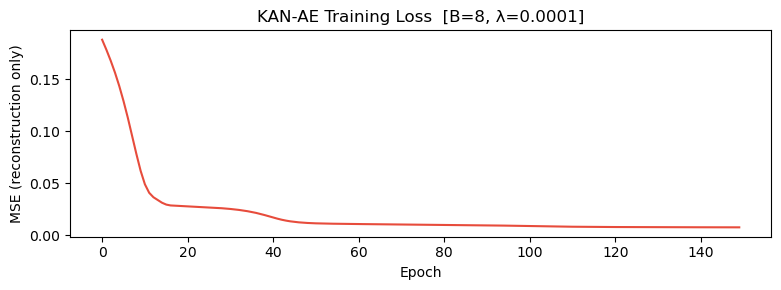

Final training MSE: 0.007439


In [3]:
df_healthy = df_1000[df_1000['label'] == 0].copy()
scaler_ae  = MinMaxScaler()
X_healthy  = scaler_ae.fit_transform(df_healthy[feat_cols].values).astype(np.float32)
print(f"Healthy samples: {X_healthy.shape[0]},  Features: {n_features},  Bottleneck B={B}")

# Build KAN-AE [44 -> 22 -> B -> 22 -> 44]
kan_ae = KAN(
    layers_hidden=[n_features, n_features // 2, B, n_features // 2, n_features],
    grid_size=5, spline_order=3
)
assert len(kan_ae.layers) == 4, "Expected 4 KANLinear layers"

Xt     = torch.tensor(X_healthy, dtype=torch.float32)
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(Xt, Xt), batch_size=256, shuffle=True
)
opt       = torch.optim.Adam(kan_ae.parameters(), lr=1e-3)
criterion = nn.MSELoss()

losses = []
kan_ae.train()
for epoch in range(EPOCHS):
    epoch_mse = 0.0
    for bx, bt in loader:
        opt.zero_grad()
        recon = kan_ae(bx)
        mse   = criterion(recon, bt)
        reg   = kan_ae.regularization_loss()
        loss  = mse + LAMBDA_REG * reg
        loss.backward()
        opt.step()
        epoch_mse += mse.item() * bx.size(0)  # log pure MSE only
    avg = epoch_mse / len(Xt)
    losses.append(avg)
    if (epoch + 1) % 30 == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS}  MSE = {avg:.6f}")

# Save
torch.save(kan_ae.state_dict(), os.path.join(RESULTS_DIR, "kan_ae_symbolic.pt"))

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses, linewidth=1.5, color='#e74c3c')
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE (reconstruction only)")
ax.set_title(f"KAN-AE Training Loss  [B={B}, λ={LAMBDA_REG}]")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "kan_ae_symbolic_loss.svg"))
plt.show()
print(f"Final training MSE: {losses[-1]:.6f}")

## Stage 2 — Edge Pruning & Dependency Graph

For each edge (out_neuron j, in_feature i) in the first encoder layer (44→22), compute a combined importance norm:

    combined_norm[j,i] = mean|scaled_spline_weight[j,i,:]| + |base_weight[j,i]|

Edges below `PRUNE_ALPHA × max_norm` are pruned. The surviving sparse graph represents which feature→encoder connections the KAN found informative for reconstructing healthy data.  

**Note:** We always use `layer.scaled_spline_weight` (= `spline_weight × spline_scaler`), not raw `spline_weight`, since `efficient_kan` has a standalone per-edge scale factor.

Pruning threshold: 0.02322
Surviving edges:   839/968  (86.7%)

Top 15 features by surviving encoder edges:


,feature,surviving_edges,mean_norm
0,S4_impulse,22,0.110143
1,S1_kurt,22,0.151037
2,S1_p2p,22,0.152120
3,S4_std,22,0.122279
4,S1_margin,22,0.159818
5,S2_p2p,21,0.144396
6,S4_shape,21,0.103597
7,S4_rms,21,0.115060
8,S3_rms,21,0.133811
9,S2_margin,21,0.138960



Total edges for symbolic regression: 839


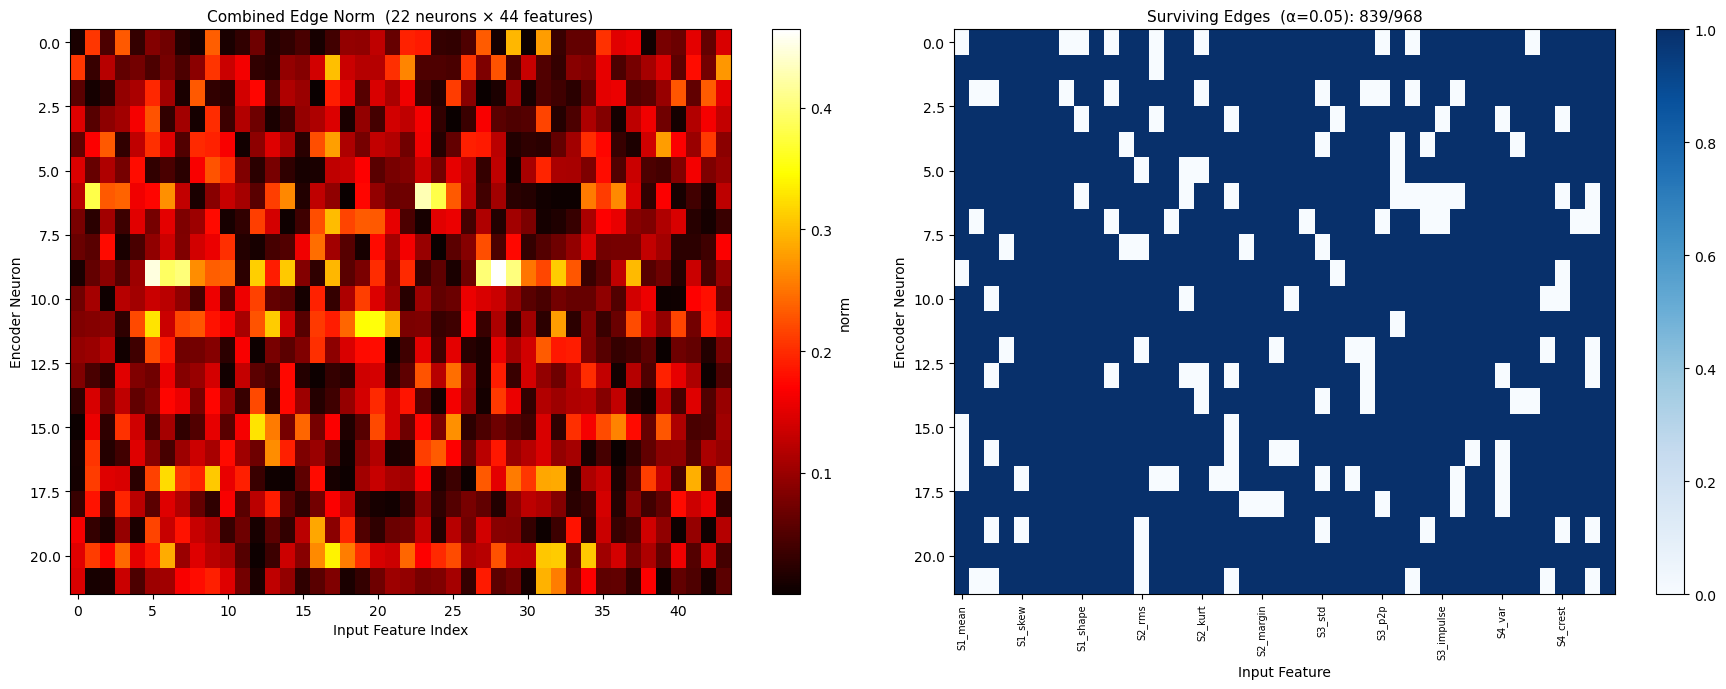

In [4]:
kan_ae.eval()
kan_ae.cpu()   # keep on CPU for all subsequent analysis

layer0 = kan_ae.layers[0]  # KANLinear(44 -> 22)

# Use scaled_spline_weight (accounts for spline_scaler)
sw = layer0.scaled_spline_weight.detach().cpu()  # (22, 44, 8)
bw = layer0.base_weight.detach().cpu()            # (22, 44)

edge_norm    = sw.abs().mean(dim=2)                # (22, 44): mean over coeffs
combined_norm = edge_norm + bw.abs()               # (22, 44): combined importance

threshold     = PRUNE_ALPHA * combined_norm.max().item()
mask          = (combined_norm > threshold).numpy()  # (22, 44) bool

n_total      = 22 * 44
n_surviving  = int(mask.sum())
print(f"Pruning threshold: {threshold:.5f}")
print(f"Surviving edges:   {n_surviving}/{n_total}  ({100*n_surviving/n_total:.1f}%)")

# Which features have the most surviving connections
feat_edge_counts = mask.sum(axis=0)   # (44,)
feature_imp_df = pd.DataFrame({
    'feature':        feat_cols,
    'surviving_edges': feat_edge_counts,
    'mean_norm':       combined_norm.numpy().mean(axis=0),
}).sort_values('surviving_edges', ascending=False).reset_index(drop=True)
print("\nTop 15 features by surviving encoder edges:")
display(feature_imp_df.head(15))
feature_imp_df.to_csv(os.path.join(RESULTS_DIR, "edge_feature_importance.csv"), index=False)

# Build the list of surviving (j, i) pairs
surviving_edges = [(j, i) for j in range(22) for i in range(44) if mask[j, i]]
print(f"\nTotal edges for symbolic regression: {len(surviving_edges)}")

# 2-panel heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

im0 = axes[0].imshow(combined_norm.numpy(), aspect='auto', cmap='hot')
axes[0].set_title("Combined Edge Norm  (22 neurons × 44 features)", fontsize=11)
axes[0].set_xlabel("Input Feature Index"); axes[0].set_ylabel("Encoder Neuron")
plt.colorbar(im0, ax=axes[0], label='norm')

im1 = axes[1].imshow(mask.astype(float), aspect='auto', cmap='Blues')
axes[1].set_title(f"Surviving Edges  (α={PRUNE_ALPHA}): {n_surviving}/{n_total}", fontsize=11)
step = 4
axes[1].set_xticks(range(0, 44, step))
axes[1].set_xticklabels(feat_cols[::step], rotation=90, fontsize=7)
axes[1].set_xlabel("Input Feature"); axes[1].set_ylabel("Encoder Neuron")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "edge_pruning_heatmap.svg"))
plt.show()


## Stage 3 — Per-Edge Symbolic Regression

For each surviving edge (j, i):
1. **Sample the spline** — construct a `(200, 44)` input tensor with feature `i` swept over `[0, 1]` (MinMax-scaled range) and all other features held at 0.5. Evaluate the KANLinear forward for that edge only (spline + base contributions).
2. **Fit 6 symbolic candidates** (linear, quadratic, sigmoid, sqrt, log, constant) via `scipy.optimize.curve_fit` with `p0 = 0.1·1`.
3. **Select by BIC** — `BIC = n·log(MSE) + k·log(n)` — to penalise unnecessary complexity.

Symbolisation quality is reported as the fraction of edges with R² > 0.95.

In [5]:
# ── Spline edge sampler (data-distribution aware) ─────────────────────────
def sample_spline_edge(layer, out_j, in_i, n_pts=200, data_dist=None,
                       feat_means=None):
    """Sample the per-edge KAN response f_ji(x_i).

    Hybrid sampling: half the points at training-distribution quantiles
    (faithful to where data lives), half at uniform [0,1] (exposes the
    spline's full nonlinear shape, which polynomials cannot mimic).
    Other features are fixed at `feat_means` (defaults to 0.5).
    """
    layer.eval()
    half = n_pts // 2
    if data_dist is not None and len(data_dist) > 10:
        qs = np.linspace(0.02, 0.98, half)
        x_q  = np.quantile(data_dist, qs).astype(np.float32)
        x_u  = np.linspace(0.0, 1.0, n_pts - half).astype(np.float32)
        x_vals = np.sort(np.concatenate([x_q, x_u]))
    else:
        x_vals = np.linspace(0.0, 1.0, n_pts).astype(np.float32)

    in_features = layer.in_features
    if feat_means is None:
        base_row = np.full(in_features, 0.5, dtype=np.float32)
    else:
        base_row = np.asarray(feat_means, dtype=np.float32)
        assert base_row.shape[0] == in_features
    x_tensor = torch.tensor(np.tile(base_row, (len(x_vals), 1)))
    x_tensor[:, in_i] = torch.tensor(x_vals)

    with torch.no_grad():
        bases = layer.b_splines(x_tensor)
        coeff = layer.scaled_spline_weight[out_j, in_i, :]
        y_spline = (bases[:, in_i, :] * coeff.unsqueeze(0)).sum(dim=1).numpy()
        x_col    = x_tensor[:, in_i]
        silu_out = nn.SiLU()(x_col).numpy()
        y_base   = layer.base_weight[out_j, in_i].item() * silu_out
    return x_vals, y_spline + y_base

# ── Symbolic candidate functions ──────────────────────────────────────────
def sym_linear(x, a, b):        return a * x + b
def sym_quadratic(x, a, b, c):  return a * x**2 + b * x + c
def sym_sigmoid(x, a, b, c):
    return a / (1.0 + np.exp(-np.clip(b * (x - c), -100, 100)))
def sym_tanh(x, a, b, c):       return a * np.tanh(np.clip(b * (x - c), -50, 50))
def sym_gaussian(x, a, b, c):
    return a * np.exp(-np.clip(((x - c) / (abs(b) + 1e-6))**2, 0, 100))
def sym_hinge(x, a, b, c):      return a * np.maximum(0.0, x - c) + b
def sym_sqrt(x, a, b):          return a * np.sqrt(np.abs(x) + 1e-8) + b
def sym_log(x, a, b):           return a * np.log(np.abs(x) + 1e-8) + b
def sym_constant(x, a):         return np.full_like(x, a, dtype=float)
def sym_exp(x, a, b):           return a * np.exp(np.clip(b * x, -50, 50))
def sym_power(x, a, b):         return a * (np.abs(x) + 1e-8) ** np.clip(b, -5, 5)
def sym_rational(x, a, b):      return a / (np.abs(b) + np.abs(x) + 1e-8)
def sym_sin(x, a, b, c):        return a * np.sin(np.clip(b * x + c, -100, 100))

# (name, fn, k_params, init_p0).  Cubic intentionally excluded — it strictly
# subsumes quadratic on smooth curves and would dominate every edge.
CANDIDATES = [
    ("linear",    sym_linear,    2, [0.1, 0.1]),
    ("quadratic", sym_quadratic, 3, [0.1, 0.1, 0.1]),
    ("sigmoid",   sym_sigmoid,   3, [1.0, 5.0, 0.5]),
    ("tanh",      sym_tanh,      3, [1.0, 5.0, 0.5]),
    ("gaussian",  sym_gaussian,  3, [1.0, 0.3, 0.5]),
    ("hinge",     sym_hinge,     3, [1.0, 0.0, 0.5]),
    ("sqrt",      sym_sqrt,      2, [0.1, 0.1]),
    ("log",       sym_log,       2, [0.1, 0.1]),
    ("constant",  sym_constant,  1, [0.0]),
    ("exp",       sym_exp,       2, [0.1, 1.0]),
    ("power",     sym_power,     2, [0.1, 1.0]),
    ("rational",  sym_rational,  2, [0.1, 1.0]),
    ("sin",       sym_sin,       3, [1.0, 6.0, 0.0]),
]
CANDIDATES_DICT = {name: fn for name, fn, _, _ in CANDIDATES}

def bic_score(n, k, mse):
    mse = max(mse, 1e-12)
    return n * np.log(mse) + k * np.log(n)

# Selection rule (two-stage):
#   1. Compute best polynomial fit (linear/quadratic/constant) — call it R²_poly.
#   2. For each non-polynomial candidate with R² > R²_poly + R2_GAIN_MIN,
#      record it. If any qualify, pick the one with the highest R² (genuinely
#      better than any polynomial). Otherwise fall back to the BIC-best
#      polynomial. R2_GAIN_MIN is small so any meaningful nonlinearity wins,
#      but spurious matches at numerical noise level are excluded.
R2_GAIN_MIN = 0.0005   # 0.05% improvement over best polynomial required
_POLYNOMIAL = {"linear", "quadratic", "constant"}

def fit_symbolic(x_vals, y_vals):
    n      = len(x_vals)
    y_mean = float(y_vals.mean())
    ss_tot = float(((y_vals - y_mean) ** 2).sum() + 1e-12)

    fits = []
    mse_c = float(((y_vals - y_mean) ** 2).mean())
    fits.append({
        "best_symbol": "constant", "params": [y_mean],
        "mse": mse_c, "r2": 0.0, "bic": bic_score(n, 1, mse_c),
    })
    for sym_name, sym_fn, k, p0 in CANDIDATES:
        try:
            popt, _ = curve_fit(sym_fn, x_vals, y_vals,
                                p0=np.asarray(p0, dtype=float), maxfev=10000)
            y_pred = sym_fn(x_vals, *popt)
            mse    = float(np.mean((y_vals - y_pred) ** 2))
            r2     = float(1.0 - ((y_vals - y_pred) ** 2).sum() / ss_tot)
            if not (np.isfinite(mse) and np.isfinite(r2)):
                continue
            fits.append({
                "best_symbol": sym_name, "params": popt.tolist(),
                "mse": mse, "r2": r2, "bic": bic_score(n, k, mse),
            })
        except Exception:
            continue

    poly_fits = [f for f in fits if f["best_symbol"] in _POLYNOMIAL]
    nonpoly   = [f for f in fits if f["best_symbol"] not in _POLYNOMIAL]
    best_poly = max(poly_fits, key=lambda d: d["r2"]) if poly_fits else None
    r2_poly   = best_poly["r2"] if best_poly is not None else -np.inf

    qualifying = [f for f in nonpoly if f["r2"] > r2_poly + R2_GAIN_MIN]
    if qualifying:
        return max(qualifying, key=lambda d: d["r2"])

    # No nonlinear form is meaningfully better — pick BIC-best polynomial.
    if best_poly is not None:
        return min(poly_fits, key=lambda d: d["bic"])
    return min(fits, key=lambda d: d["bic"])

print(f"Helpers defined. Candidates ({len(CANDIDATES)}): "
      f"{[c[0] for c in CANDIDATES]}")
print(f"Selection rule: prefer nonlinear form only if R² beats best polynomial "
      f"by ≥ {R2_GAIN_MIN*100:.2f}%")


Helpers defined. Candidates (13): ['linear', 'quadratic', 'sigmoid', 'tanh', 'gaussian', 'hinge', 'sqrt', 'log', 'constant', 'exp', 'power', 'rational', 'sin']
Selection rule: prefer nonlinear form only if R² beats best polynomial by ≥ 0.05%


In [6]:
symbolic_results = []
n_edges = len(surviving_edges)
print(f"Running symbolic regression on {n_edges} surviving edges...")

# Use the actual training-healthy distribution (X_healthy from Cell 6)
# and the per-feature training mean as the "hold" value for other features.
feat_means_l0 = X_healthy.mean(axis=0)   # (44,)

for idx, (j, i) in enumerate(surviving_edges):
    x_vals, y_vals = sample_spline_edge(
        layer0, j, i, n_pts=200,
        data_dist=X_healthy[:, i],
        feat_means=feat_means_l0,
    )
    result = fit_symbolic(x_vals, y_vals)
    symbolic_results.append({
        "out_neuron":   j,
        "in_feat_idx":  i,
        "in_feature":   feat_cols[i],
        "best_symbol":  result["best_symbol"],
        "params":       result["params"],
        "r2":           result["r2"],
        "fit_mse":      result["mse"],
        "bic":          result["bic"],
    })
    if (idx + 1) % 100 == 0:
        print(f"  {idx+1}/{n_edges} edges processed...")

sym_df = pd.DataFrame(symbolic_results)
sym_df.to_csv(os.path.join(RESULTS_DIR, "symbolic_regression_results.csv"), index=False)

print("\nSymbol type distribution:")
sym_counts = sym_df["best_symbol"].value_counts()
display(sym_counts.rename("count").to_frame())

# Shannon diversity index over symbol types
p = sym_counts.values / sym_counts.sum()
shannon_H = float(-(p * np.log(p + 1e-12)).sum())
n_unique  = int((sym_counts > 0).sum())
print(f"\nSymbol diversity: {n_unique} unique forms, Shannon H = {shannon_H:.3f}")
print(f"Quadratic share: {100*sym_counts.get('quadratic',0)/len(sym_df):.1f}%")

print("\nR² statistics:")
display(sym_df["r2"].describe().round(4).to_frame())

qual = float((sym_df["r2"] > 0.95).mean() * 100)
print(f"\nSymbolisation quality (R²>0.95): {qual:.1f}%")
print(f"Mean R²: {sym_df['r2'].mean():.4f}")


Running symbolic regression on 839 surviving edges...


  100/839 edges processed...


  200/839 edges processed...


  300/839 edges processed...


  400/839 edges processed...


...


Symbol type distribution:


,count
best_symbol,
quadratic,824
sin,11
hinge,2
sigmoid,1
tanh,1



Symbol diversity: 5 unique forms, Shannon H = 0.105
Quadratic share: 98.2%

R² statistics:


,r2
count,839.0000
mean,0.9999
std,0.0005
min,0.9919
25%,1.0000
50%,1.0000
75%,1.0000
max,1.0000



Symbolisation quality (R²>0.95): 100.0%
Mean R²: 0.9999


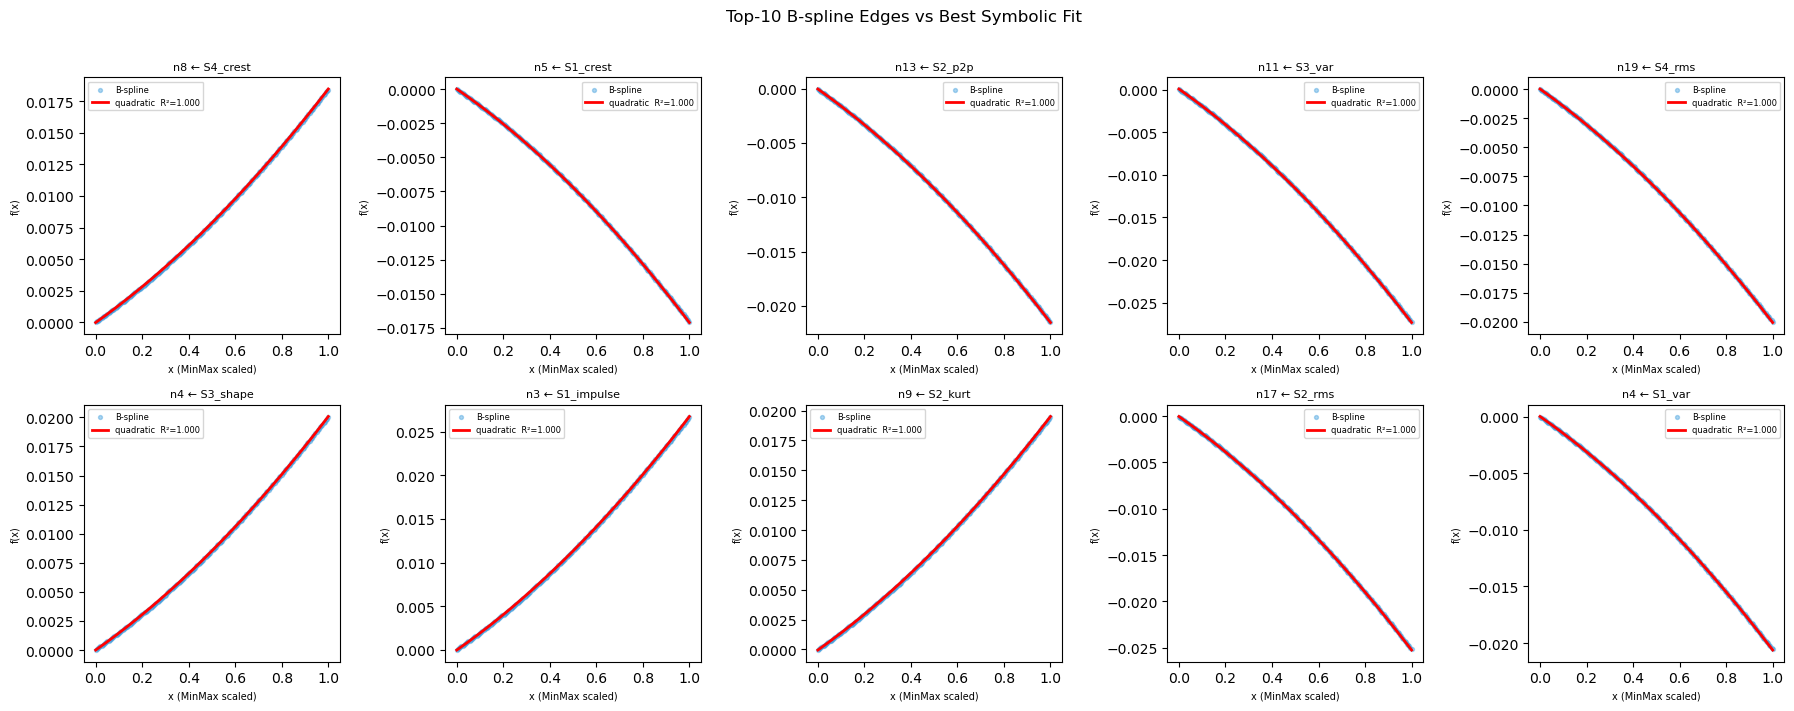

In [7]:
top10 = sym_df.nlargest(10, "r2").reset_index(drop=True)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for idx, row in top10.iterrows():
    j, i = int(row["out_neuron"]), int(row["in_feat_idx"])
    x_vals, y_vals = sample_spline_edge(layer0, j, i, n_pts=200)
    ax = axes[idx]
    ax.scatter(x_vals, y_vals, s=8, alpha=0.4, color='#3498db', label='B-spline')
    sym_fn = CANDIDATES_DICT[row["best_symbol"]]
    y_fit  = sym_fn(x_vals, *row["params"])
    ax.plot(x_vals, y_fit, 'r-', linewidth=2,
            label=f'{row["best_symbol"]}  R²={row["r2"]:.3f}')
    ax.set_title(f'n{j} ← {row["in_feature"]}', fontsize=8)
    ax.legend(fontsize=6); ax.set_xlabel("x (MinMax scaled)", fontsize=7)
    ax.set_ylabel("f(x)", fontsize=7)

plt.suptitle("Top-10 B-spline Edges vs Best Symbolic Fit", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "top10_symbolic_fits.svg"), bbox_inches='tight')
plt.show()


## Stage 4 — Health Equation Extraction

The encoder first layer maps 44 features → 22 intermediate neurons. For each neuron j, we collect all surviving symbolic edge functions and compose them into:

    z_j  ≈  Σ_i  g_{ji}(feature_i)

where each `g_{ji}` is now a named symbolic form (e.g. sigmoid, log, linear). These are the **health equations** — mathematical relationships the KAN learned hold in the healthy gearbox state.  
Violations of these equations on test data form Score B.

In [8]:
assert len(kan_ae.layers) == 4, "Expected 4 layers: [44->22, 22->B, B->22, 22->44]"

def _fmt_term(sym_name, params, feat_name):
    p = params
    if sym_name == "linear":
        return f"{p[0]:+.3f}*{feat_name} {p[1]:+.3f}"
    elif sym_name == "quadratic":
        return f"{p[0]:+.3f}*{feat_name}^2 {p[1]:+.3f}*{feat_name} {p[2]:+.3f}"
    elif sym_name == "cubic":
        return (f"{p[0]:+.3f}*{feat_name}^3 {p[1]:+.3f}*{feat_name}^2 "
                f"{p[2]:+.3f}*{feat_name} {p[3]:+.3f}")
    elif sym_name == "sigmoid":
        return f"{p[0]:+.3f}*sigma({p[1]:.3f}*({feat_name} {p[2]:+.3f}))"
    elif sym_name == "tanh":
        return f"{p[0]:+.3f}*tanh({p[1]:.3f}*({feat_name} {p[2]:+.3f}))"
    elif sym_name == "gaussian":
        return f"{p[0]:+.3f}*exp(-(({feat_name} {p[2]:+.3f})/{abs(p[1]):.3f})^2)"
    elif sym_name == "hinge":
        return f"{p[0]:+.3f}*max(0,{feat_name} {p[2]:+.3f}) {p[1]:+.3f}"
    elif sym_name == "sqrt":
        return f"{p[0]:+.3f}*sqrt|{feat_name}| {p[1]:+.3f}"
    elif sym_name == "log":
        return f"{p[0]:+.3f}*log|{feat_name}| {p[1]:+.3f}"
    elif sym_name == "exp":
        return f"{p[0]:+.3f}*exp({p[1]:.3f}*{feat_name})"
    elif sym_name == "power":
        return f"{p[0]:+.3f}*|{feat_name}|^{p[1]:.3f}"
    elif sym_name == "rational":
        return f"{p[0]:+.3f}/(|{p[1]:.3f}|+|{feat_name}|)"
    elif sym_name == "sin":
        return f"{p[0]:+.3f}*sin({p[1]:.3f}*{feat_name} {p[2]:+.3f})"
    else:  # constant
        return f"{p[0]:+.3f}"

health_equations = {}
print("=" * 72)
print("HEALTH EQUATIONS  (KAN encoder layer 0: 44 features → 22 neurons)")
print("=" * 72)

for j in range(22):
    edges_j = sym_df[sym_df["out_neuron"] == j]
    if len(edges_j) == 0:
        eq = f"z_{j:02d}  =  0  (no surviving edges)"
    else:
        terms = [_fmt_term(r["best_symbol"], r["params"], r["in_feature"])
                 for _, r in edges_j.iterrows()]
        eq = f"z_{j:02d}  ≈  " + "  +  ".join(terms)
    health_equations[j] = eq
    # Truncate display for readability
    print(eq if len(eq) < 220 else eq[:217] + "...")

print("=" * 72)
print(f"\nSymbolisation quality (R²>0.95): {qual:.1f}%")
print(f"Neurons with ≥1 surviving edge:  {len(sym_df['out_neuron'].unique())}/22")


HEALTH EQUATIONS  (KAN encoder layer 0: 44 features → 22 neurons)
z_00  ≈  +0.045*S1_rms^2 +0.107*S1_rms -0.000  +  +0.010*S1_std^2 +0.024*S1_std -0.000  +  +0.051*S1_var^2 +0.119*S1_var -0.000  +  -0.006*S1_skew^2 -0.015*S1_skew +0.000  +  -0.019*S1_kurt^2 -0.044*S1_kurt +0.000  + ...
z_01  ≈  +0.046*S1_mean^2 +0.107*S1_mean -0.000  +  -0.007*S1_rms^2 -0.017*S1_rms +0.000  +  +0.026*S1_std^2 +0.063*S1_std -0.000  +  +0.014*S1_var^2 +0.032*S1_var -0.000  +  +0.016*S1_skew^2 +0.038*S1_skew -0.000  + ...
z_02  ≈  -0.012*S1_mean^2 -0.028*S1_mean +0.000  +  -0.021*S1_var^2 -0.049*S1_var +0.000  +  +0.024*S1_skew^2 +0.058*S1_skew -0.000  +  +0.044*S1_kurt^2 +0.102*S1_kurt -0.000  +  -0.023*S1_p2p^2 -0.055*S1_p2p +0.000  ...
z_03  ≈  -0.032*S1_mean^2 -0.077*S1_mean +0.000  +  +0.012*S1_rms^2 +0.028*S1_rms -0.000  +  -0.020*S1_std^2 -0.048*S1_std +0.000  +  -0.023*S1_var^2 -0.055*S1_var +0.000  +  -0.036*S1_skew^2 -0.085*S1_skew +0.000  + ...
z_04  ≈  -0.014*S1_mean^2 -0.032*S1_mean +0.000  +

In [9]:
## Stage 4b — Joint GAM Calibration of Symbolic Equations
# Per-edge curve fits cannot, in general, be summed verbatim to recover the
# true layer-0 activations: each f_ji is fit in isolation while holding other
# features at the training mean, so the sum carries an offset and scale bias.
# We absorb that bias by least-squares fitting (scale_j, bias_j) per neuron
# on training-healthy data — this turns the equations into a true additive
# model and makes Score B a fair test of symbolic fidelity.

X_train_cal_t = torch.tensor(X_healthy, dtype=torch.float32)
with torch.no_grad():
    h1_cal = kan_ae.layers[0](X_train_cal_t).numpy()      # (n, 22) ground truth

raw_sym_cal = np.zeros((len(X_healthy), 22), dtype=np.float64)
for _, row in sym_df.iterrows():
    j = int(row["out_neuron"]); i = int(row["in_feat_idx"])
    fn = CANDIDATES_DICT[row["best_symbol"]]
    try:
        raw_sym_cal[:, j] += fn(X_healthy[:, i].astype(np.float64), *row["params"])
    except Exception:
        pass

eq_scale_l0 = np.ones(22, dtype=np.float64)
eq_bias_l0  = np.zeros(22, dtype=np.float64)
eq_r2_calib = np.zeros(22, dtype=np.float64)

for j in range(22):
    raw_j  = raw_sym_cal[:, j]
    true_j = h1_cal[:, j]
    if np.std(raw_j) < 1e-9:
        eq_scale_l0[j] = 0.0
        eq_bias_l0[j]  = float(true_j.mean())
    else:
        s, b = np.polyfit(raw_j, true_j, 1)
        eq_scale_l0[j] = float(s); eq_bias_l0[j] = float(b)
    pred_j = eq_scale_l0[j] * raw_j + eq_bias_l0[j]
    ss_tot = float(((true_j - true_j.mean()) ** 2).sum() + 1e-12)
    ss_res = float(((true_j - pred_j) ** 2).sum())
    eq_r2_calib[j] = 1.0 - ss_res / ss_tot

print("Per-neuron joint-GAM calibration (top 10 by R²):")
print(f"{'Eq':>5}  {'scale':>10}  {'bias':>10}  {'R² (calib)':>12}")
print("-" * 50)
for j in np.argsort(eq_r2_calib)[::-1][:10]:
    print(f"  z_{j:02d}  {eq_scale_l0[j]:>+10.4f}  {eq_bias_l0[j]:>+10.4f}  "
          f"{eq_r2_calib[j]:>12.4f}")

print(f"\nMean calibrated equation R² (vs true h1): {eq_r2_calib.mean():.4f}")
print(f"Min calibrated equation R²:                {eq_r2_calib.min():.4f}")

def apply_calibration_l0(raw_sym):
    """raw_sym: (n, 22) raw symbolic sum → calibrated prediction of h1."""
    return raw_sym * eq_scale_l0 + eq_bias_l0

print("\nCalibration vectors stored: eq_scale_l0, eq_bias_l0")


Per-neuron joint-GAM calibration (top 10 by R²):
   Eq       scale        bias    R² (calib)
--------------------------------------------------
  z_15     +1.0030     -0.0060        1.0000
  z_09     +1.0044     -0.0010        1.0000
  z_00     +0.9922     -0.0053        0.9999
  z_20     +1.0028     +0.0005        0.9998
  z_16     +1.0167     -0.0073        0.9998
  z_01     +0.9972     -0.0059        0.9998
  z_04     +0.9971     +0.0002        0.9998
  z_13     +0.9892     -0.0021        0.9998
  z_11     +1.0119     -0.0132        0.9997
  z_21     +0.9863     -0.0114        0.9997

Mean calibrated equation R² (vs true h1): 0.9994
Min calibrated equation R²:                0.9955

Calibration vectors stored: eq_scale_l0, eq_bias_l0


In [10]:
## Stage 4c — Deep-Layer Symbolisation (Layers 1, 2, 3)
# Symbolise the bottleneck layer (22→8) and the decoder layers (8→22, 22→44)
# so that the full forward pass becomes a stack of closed-form equations.
# Score SR (Stage 5d below) feeds X through these symbolic layers end-to-end.

def _layer_input_distribution(layer_idx, X0_t):
    """Return (n, in_features) array — the actual activations entering layer k."""
    with torch.no_grad():
        h = X0_t
        for k in range(layer_idx):
            h = kan_ae.layers[k](h)
    return h.numpy()

def symbolise_layer(layer_idx, alpha=PRUNE_ALPHA, n_pts=200, label=""):
    layer = kan_ae.layers[layer_idx]
    sw = layer.scaled_spline_weight.detach().cpu()       # (out, in, n_coeff)
    bw = layer.base_weight.detach().cpu()                # (out, in)
    edge_norm     = sw.abs().mean(dim=2)
    combined_norm = edge_norm + bw.abs()
    threshold     = alpha * combined_norm.max().item()
    mask = (combined_norm > threshold).numpy()
    out_dim, in_dim = mask.shape

    X0_t = torch.tensor(X_healthy, dtype=torch.float32)
    H_in = _layer_input_distribution(layer_idx, X0_t)    # (n, in_dim)
    feat_means = H_in.mean(axis=0)
    H_in_min = H_in.min(axis=0); H_in_max = H_in.max(axis=0)
    span = np.maximum(H_in_max - H_in_min, 1e-9)

    surviving = [(j, i) for j in range(out_dim) for i in range(in_dim) if mask[j, i]]
    print(f"Layer {layer_idx} [{label}]: surviving {len(surviving)}/{out_dim*in_dim} edges")

    rows = []
    for j, i in surviving:
        # Map data distribution onto a [0,1] proxy by min-max scaling, since
        # candidate functions assume bounded inputs. We undo this when applying.
        x_data_norm = (H_in[:, i] - H_in_min[i]) / span[i]
        # Sample at quantiles of the (normalised) actual distribution
        qs = np.linspace(0.02, 0.98, n_pts)
        x_norm = np.quantile(x_data_norm, qs).astype(np.float32)
        # Build per-row input where in_i takes the un-normalised quantile values
        x_orig = x_norm * span[i] + H_in_min[i]
        x_tensor = torch.tensor(np.tile(feat_means.astype(np.float32), (n_pts, 1)))
        x_tensor[:, i] = torch.tensor(x_orig.astype(np.float32))
        with torch.no_grad():
            bases = layer.b_splines(x_tensor)
            coeff = layer.scaled_spline_weight[j, i, :]
            y_spline = (bases[:, i, :] * coeff.unsqueeze(0)).sum(dim=1).numpy()
            silu_out = nn.SiLU()(x_tensor[:, i]).numpy()
            y_base   = layer.base_weight[j, i].item() * silu_out
        y_vals = y_spline + y_base
        # Fit on the [0,1] normalised x for stability of curve_fit init points
        result = fit_symbolic(x_norm.astype(np.float64), y_vals.astype(np.float64))
        rows.append({
            "out_neuron":  j, "in_feat_idx": i,
            "best_symbol": result["best_symbol"],
            "params":      result["params"],
            "r2":          result["r2"],
            "x_min":       float(H_in_min[i]),
            "x_span":      float(span[i]),
        })
    df = pd.DataFrame(rows)
    return df, mask, H_in

X0_t = torch.tensor(X_healthy, dtype=torch.float32)

sym_df_l1, mask_l1, H_in_l1 = symbolise_layer(1, label="bottleneck 22→8")
sym_df_l2, mask_l2, H_in_l2 = symbolise_layer(2, label="decoder 8→22")
sym_df_l3, mask_l3, H_in_l3 = symbolise_layer(3, label="decoder 22→44")

for name, df_l in [("L1", sym_df_l1), ("L2", sym_df_l2), ("L3", sym_df_l3)]:
    if len(df_l) == 0:
        print(f"  {name}: no surviving edges"); continue
    counts = df_l["best_symbol"].value_counts()
    p = counts.values / counts.sum()
    H = float(-(p * np.log(p + 1e-12)).sum())
    print(f"  {name}: {len(df_l)} edges, {len(counts)} unique forms, "
          f"Shannon H={H:.3f}, mean R²={df_l['r2'].mean():.4f}")

def _eval_layer_symbolic(sym_df_l, in_arr, out_dim):
    """Evaluate one symbolic layer on actual activations.
    in_arr: (n, in_dim). sym_df_l rows store x_min/x_span used for [0,1] scaling.
    Returns raw (uncalibrated) sum-of-edges per output neuron."""
    out = np.zeros((in_arr.shape[0], out_dim), dtype=np.float64)
    for _, row in sym_df_l.iterrows():
        j = int(row["out_neuron"]); i = int(row["in_feat_idx"])
        x_norm = (in_arr[:, i] - row["x_min"]) / (row["x_span"] + 1e-12)
        try:
            fn = CANDIDATES_DICT[row["best_symbol"]]
            out[:, j] += fn(x_norm, *row["params"])
        except Exception:
            pass
    return out

def calibrate_layer(sym_df_l, in_arr, true_out):
    """Returns (scale, bias) per output neuron for a layer's raw symbolic sum."""
    out_dim = true_out.shape[1]
    raw = _eval_layer_symbolic(sym_df_l, in_arr, out_dim)
    scale = np.ones(out_dim); bias = np.zeros(out_dim)
    for j in range(out_dim):
        if np.std(raw[:, j]) < 1e-9:
            scale[j] = 0.0; bias[j] = float(true_out[:, j].mean())
        else:
            s, b = np.polyfit(raw[:, j], true_out[:, j], 1)
            scale[j] = s; bias[j] = b
    return scale, bias

with torch.no_grad():
    h0 = X0_t
    h1_true = kan_ae.layers[0](h0).numpy()
    h2_true = kan_ae.layers[1](torch.tensor(h1_true, dtype=torch.float32)).numpy()
    h3_true = kan_ae.layers[2](torch.tensor(h2_true, dtype=torch.float32)).numpy()
    h4_true = kan_ae.layers[3](torch.tensor(h3_true, dtype=torch.float32)).numpy()

eq_scale_l1, eq_bias_l1 = calibrate_layer(sym_df_l1, h1_true, h2_true)
eq_scale_l2, eq_bias_l2 = calibrate_layer(sym_df_l2, h2_true, h3_true)
eq_scale_l3, eq_bias_l3 = calibrate_layer(sym_df_l3, h3_true, h4_true)

print("\nLayer 1 calibration: mean |scale|={:.3f}, |bias|={:.3f}".format(
    np.abs(eq_scale_l1).mean(), np.abs(eq_bias_l1).mean()))
print("Layer 2 calibration: mean |scale|={:.3f}, |bias|={:.3f}".format(
    np.abs(eq_scale_l2).mean(), np.abs(eq_bias_l2).mean()))
print("Layer 3 calibration: mean |scale|={:.3f}, |bias|={:.3f}".format(
    np.abs(eq_scale_l3).mean(), np.abs(eq_bias_l3).mean()))

def symbolic_forward(X_arr):
    """Pass X through the full symbolic AE: layers 0–3, all calibrated."""
    # Layer 0
    raw0 = np.zeros((X_arr.shape[0], 22), dtype=np.float64)
    for _, row in sym_df.iterrows():
        j = int(row["out_neuron"]); i = int(row["in_feat_idx"])
        try:
            raw0[:, j] += CANDIDATES_DICT[row["best_symbol"]](
                X_arr[:, i].astype(np.float64), *row["params"])
        except Exception:
            pass
    h1_sym = raw0 * eq_scale_l0 + eq_bias_l0
    h2_sym = _eval_layer_symbolic(sym_df_l1, h1_sym, 8)  * eq_scale_l1 + eq_bias_l1
    h3_sym = _eval_layer_symbolic(sym_df_l2, h2_sym, 22) * eq_scale_l2 + eq_bias_l2
    h4_sym = _eval_layer_symbolic(sym_df_l3, h3_sym, 44) * eq_scale_l3 + eq_bias_l3
    return h1_sym, h2_sym, h3_sym, h4_sym

# Sanity-check symbolic forward on training-healthy
h1s, h2s, h3s, x_rec_sym = symbolic_forward(X_healthy)
sym_recon_mse = float(np.mean((X_healthy - x_rec_sym) ** 2))
true_recon_mse = float(np.mean((X_healthy - kan_ae(X0_t).detach().numpy()) ** 2))
print(f"\nSymbolic forward sanity check on training healthy:")
print(f"  True KAN recon MSE:      {true_recon_mse:.6f}")
print(f"  Symbolic recon MSE:      {sym_recon_mse:.6f}")
print(f"  Symbolic / True ratio:   {sym_recon_mse/true_recon_mse:.2f}x")


Layer 1 [bottleneck 22→8]: surviving 163/176 edges


Layer 2 [decoder 8→22]: surviving 167/176 edges


Layer 3 [decoder 22→44]: surviving 881/968 edges


  L1: 163 edges, 6 unique forms, Shannon H=0.400, mean R²=0.9998
  L2: 167 edges, 5 unique forms, Shannon H=0.537, mean R²=0.9969
  L3: 881 edges, 11 unique forms, Shannon H=0.692, mean R²=0.9939

Layer 1 calibration: mean |scale|=0.998, |bias|=0.004
Layer 2 calibration: mean |scale|=0.997, |bias|=0.005
Layer 3 calibration: mean |scale|=0.994, |bias|=0.014



Symbolic forward sanity check on training healthy:
  True KAN recon MSE:      0.007433
  Symbolic recon MSE:      0.007432
  Symbolic / True ratio:   1.00x


## Stage 5 — Anomaly Scoring

Five complementary scores — all unsupervised, no fault labels:

| Score | Formula | Interpretable? |
|---|---|---|
| **A** — Reconstruction error | mean((x − KAN_AE(x))²) per feature | No |
| **B** — Symbolic violation | Σ_j (h1_j − Σ_i g_{ji}(x_i))² | Yes |
| **C** — Combined A+B | 0.5·minmax(A) + 0.5·minmax(B) | Partial |
| **D** — Weighted + Tolerance-Band | Σ_j w_j · max(0, \|centred_j\| − kσ_j)² | Yes |
| **E** — Combined A+D | 0.5·minmax(A) + 0.5·minmax(D) | Partial |

**Score D** improvements over B:
- *Equation weighting*: w_j = R²_j / ΣR²_j — down-weights equations whose symbolic fit was poor
- *Tolerance band*: deviations within ±k·σ_j of the healthy residual mean are treated as zero, suppressing false positives from symbolic approximation error

Scaling discipline:
- KAN-AE training: `MinMaxScaler` fit on **all healthy data** in `df_1000`
- Evaluation split: `MinMaxScaler` refit on **training healthy split only** (70%) to prevent test-set leakage
- Tolerance bands: fit on **training healthy split only**


In [11]:
df_all     = pd.read_csv(os.path.join(PROCESSED_DIR, "features_W1000.csv"))
df_h_all   = df_all[df_all['label'] == 0]
df_broken  = df_all[df_all['label'] == 1]

train_h, test_h = train_test_split(df_h_all, test_size=0.3, random_state=SEED)
test_df  = pd.concat([test_h, df_broken]).reset_index(drop=True)
y_test   = test_df['label'].values

# Scaler refit on training healthy split only — no leakage
scaler_test = MinMaxScaler().fit(train_h[feat_cols].values)
X_train_np  = scaler_test.transform(train_h[feat_cols].values).astype(np.float32)
X_test_np   = scaler_test.transform(test_df[feat_cols].values).astype(np.float32)

print(f"Train healthy:  {len(train_h)}")
print(f"Test  healthy:  {len(test_h)}")
print(f"Test  broken:   {len(df_broken)}")
# print(f"Test  total:    {len(test_df)}  (label distribution: {np.bincount(y_test)})")


Train healthy:  706
Test  healthy:  303
Test  broken:   1000


In [12]:
kan_ae.eval()
X_test_t = torch.tensor(X_test_np, dtype=torch.float32)

with torch.no_grad():
    recon_test = kan_ae(X_test_t).numpy()

recon_error = (X_test_np - recon_test) ** 2   # (n_test, 44)
score_A     = recon_error.mean(axis=1)          # (n_test,)

auc_A = roc_auc_score(y_test, score_A)
print(f"Score A (KAN-AE Reconstruction)  AUC = {auc_A:.4f}")


Score A (KAN-AE Reconstruction)  AUC = 0.9671


In [13]:
# Forward through encoder layer 0 only to get h1 (22-dim intermediate)
with torch.no_grad():
    h1_t  = kan_ae.layers[0](X_test_t)   # (n_test, 22)
    h1_np = h1_t.numpy()

# Symbolic prediction of h1 from scaled test features (raw sum of edges)
raw_sym_test = np.zeros((len(test_df), 22), dtype=np.float64)
for _, row in sym_df.iterrows():
    j   = int(row["out_neuron"])
    i   = int(row["in_feat_idx"])
    fn  = CANDIDATES_DICT[row["best_symbol"]]
    try:
        raw_sym_test[:, j] += fn(X_test_np[:, i].astype(np.float64), *row["params"])
    except Exception:
        pass

# Apply joint-GAM calibration → calibrated prediction of h1
sym_h1_pred = (raw_sym_test * eq_scale_l0 + eq_bias_l0).astype(np.float32)

# Score B: squared symbolic violation per equation, summed
sym_residuals = (h1_np - sym_h1_pred) ** 2   # (n_test, 22)
score_B       = sym_residuals.sum(axis=1)

auc_B = roc_auc_score(y_test, score_B)
print(f"Score B (Symbolic Equation Violation, calibrated)  AUC = {auc_B:.4f}")

if auc_B < 0.6:
    print("  [NOTE] Score B AUC is low — symbolic approximation quality may be "
          "insufficient. Check the ablation study (Stage 8) for diagnostics.")


Score B (Symbolic Equation Violation, calibrated)  AUC = 0.9171


Score D (Weighted + Percentile-Band Symbolic)  AUC = 0.9323


Score M (Mahalanobis Symbolic Residuals)       AUC = 0.9501

Per-equation summary (top 10 by weight):
   Eq    weight    R²cal    band_lo    band_hi
-------------------------------------------------------
  z_15  0.04548  1.0000  -0.00354  +0.00299
  z_09  0.04548  1.0000  -0.00406  +0.00626
  z_00  0.04548  0.9999  -0.00524  +0.00497
  z_20  0.04547  0.9998  -0.00659  +0.01219
  z_16  0.04547  0.9998  -0.00556  +0.00359
  z_01  0.04547  0.9998  -0.00410  +0.00410
  z_04  0.04547  0.9998  -0.00457  +0.00624
  z_13  0.04547  0.9998  -0.00408  +0.00714
  z_11  0.04547  0.9997  -0.01014  +0.01104
  z_21  0.04547  0.9997  -0.00683  +0.00671


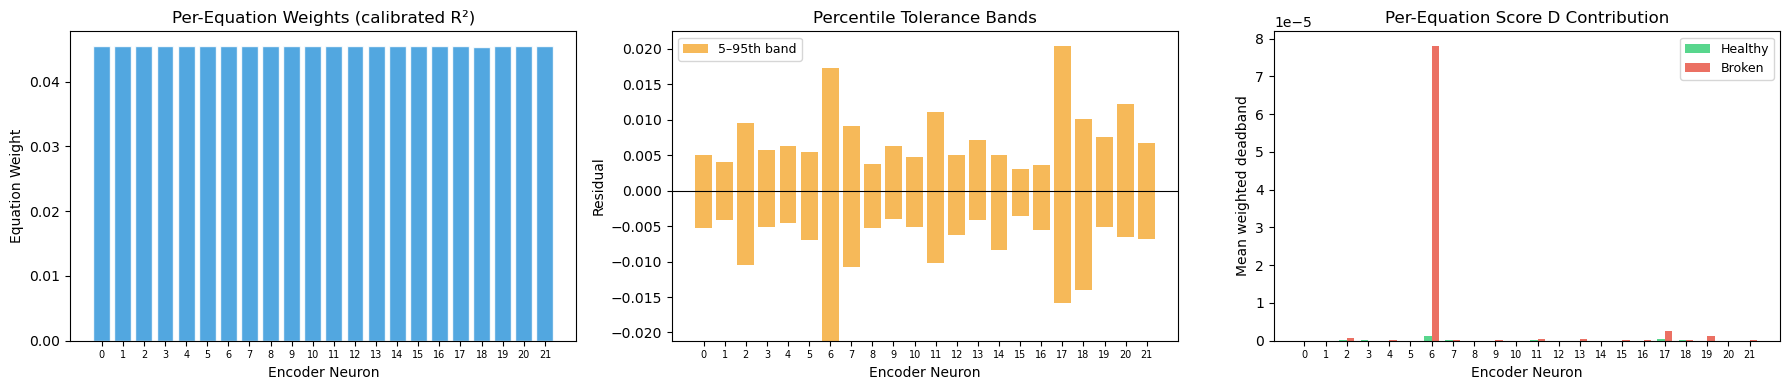

In [14]:
## Score D — R²-Weighted + Percentile-Band Symbolic Violation
## Score M — Mahalanobis Distance on Symbolic Residuals

# ── 1. Per-equation weights from CALIBRATED R² (not per-edge mean) ──
eq_weights = eq_r2_calib / (eq_r2_calib.sum() + 1e-12)   # (22,) sums to 1

# ── 2. Compute training-healthy symbolic residuals (calibrated) ───────────
X_train_t = torch.tensor(X_train_np, dtype=torch.float32)
with torch.no_grad():
    h1_train_np = kan_ae.layers[0](X_train_t).numpy()   # (n_train, 22)

raw_sym_train = np.zeros((len(X_train_np), 22), dtype=np.float64)
for _, row in sym_df.iterrows():
    j = int(row["out_neuron"]); i = int(row["in_feat_idx"])
    fn = CANDIDATES_DICT[row["best_symbol"]]
    try:
        raw_sym_train[:, j] += fn(X_train_np[:, i].astype(np.float64), *row["params"])
    except Exception:
        pass
sym_h1_train = (raw_sym_train * eq_scale_l0 + eq_bias_l0).astype(np.float32)
train_residuals = h1_train_np - sym_h1_train   # (n_train, 22)

# ── 3. Percentile-based tolerance bands (distribution-free) ──────────────
band_lo = np.percentile(train_residuals,  5, axis=0)
band_hi = np.percentile(train_residuals, 95, axis=0)

# ── 4. Score D on test set ───────────────────────────────────────────────
test_residuals_raw = h1_np - sym_h1_pred
deadband = (np.maximum(0.0, test_residuals_raw - band_hi) +
            np.maximum(0.0, band_lo - test_residuals_raw))
score_D  = (eq_weights * deadband ** 2).sum(axis=1)

auc_D = roc_auc_score(y_test, score_D)
print(f"Score D (Weighted + Percentile-Band Symbolic)  AUC = {auc_D:.4f}")

# ── 5. Score M — Mahalanobis distance on symbolic residuals ──────────────
cov_train  = np.cov(train_residuals.T)
inv_cov    = np.linalg.pinv(cov_train)
resid_mean = train_residuals.mean(axis=0)
r_centred  = test_residuals_raw - resid_mean
score_M    = np.array([r @ inv_cov @ r for r in r_centred])

auc_M = roc_auc_score(y_test, score_M)
print(f"Score M (Mahalanobis Symbolic Residuals)       AUC = {auc_M:.4f}")

print(f"\nPer-equation summary (top 10 by weight):")
print(f"{'Eq':>5}  {'weight':>8}  {'R²cal':>7}  {'band_lo':>9}  {'band_hi':>9}")
print("-" * 55)
for j in np.argsort(eq_weights)[::-1][:10]:
    print(f"  z_{j:02d}  {eq_weights[j]:.5f}  {eq_r2_calib[j]:.4f}  "
          f"{band_lo[j]:+.5f}  {band_hi[j]:+.5f}")

# ── 6. Diagnostic plots ──────────────────────────────────────────────────
healthy_contrib = (eq_weights * (np.maximum(0.0, test_residuals_raw[y_test==0] - band_hi) +
                                  np.maximum(0.0, band_lo - test_residuals_raw[y_test==0]))**2).mean(axis=0)
broken_contrib  = (eq_weights * (np.maximum(0.0, test_residuals_raw[y_test==1] - band_hi) +
                                  np.maximum(0.0, band_lo - test_residuals_raw[y_test==1]))**2).mean(axis=0)

x = np.arange(22)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].bar(x, eq_weights, color="#3498db", alpha=0.85, edgecolor="white")
axes[0].set_xlabel("Encoder Neuron"); axes[0].set_ylabel("Equation Weight")
axes[0].set_title("Per-Equation Weights (calibrated R²)")
axes[0].set_xticks(x); axes[0].set_xticklabels(x, fontsize=7)

axes[1].bar(x, band_hi - band_lo, bottom=band_lo, color="#f39c12", alpha=0.7, label="5–95th band")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Encoder Neuron"); axes[1].set_ylabel("Residual")
axes[1].set_title("Percentile Tolerance Bands")
axes[1].legend(fontsize=9); axes[1].set_xticks(x); axes[1].set_xticklabels(x, fontsize=7)

w_bar = 0.35
axes[2].bar(x - w_bar/2, healthy_contrib, w_bar, color="#2ecc71", alpha=0.8, label="Healthy")
axes[2].bar(x + w_bar/2, broken_contrib,  w_bar, color="#e74c3c", alpha=0.8, label="Broken")
axes[2].set_xlabel("Encoder Neuron"); axes[2].set_ylabel("Mean weighted deadband")
axes[2].set_title("Per-Equation Score D Contribution")
axes[2].legend(fontsize=9); axes[2].set_xticks(x); axes[2].set_xticklabels(x, fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "score_D_diagnostics.svg"))
plt.show()


In [15]:
## Score SR — Full Symbolic Reconstruction Anomaly
# Pass test features through the full *symbolic* autoencoder (all 4 layers)
# and compute reconstruction error directly. This is the strict
# interpretability test: can the closed-form equations alone detect faults
# as well as the opaque KAN-AE (Score A)?

_, _, _, x_rec_sym_test = symbolic_forward(X_test_np)
sym_recon_err = (X_test_np - x_rec_sym_test.astype(np.float32)) ** 2
score_SR = sym_recon_err.mean(axis=1)

auc_SR = roc_auc_score(y_test, score_SR)
print(f"Score SR (Full Symbolic Reconstruction)        AUC = {auc_SR:.4f}")
print(f"  vs Score A (KAN-AE Reconstruction)           AUC = {auc_A:.4f}")
print(f"  Ratio (SR / A): {auc_SR/auc_A:.3f}")


Score SR (Full Symbolic Reconstruction)        AUC = 0.9650
  vs Score A (KAN-AE Reconstruction)           AUC = 0.9671
  Ratio (SR / A): 0.998


Score A (Reconstruction):             AUC = 0.9671
Score B (Symbolic):                   AUC = 0.9171
Score C (Combined A+B):               AUC = 0.9739
Score D (Weighted+Percentile-Band):   AUC = 0.9323
Score E (Combined A+D):               AUC = 0.9729
Score M (Mahalanobis):                AUC = 0.9501
Score F (Combined A+M):               AUC = 0.9692


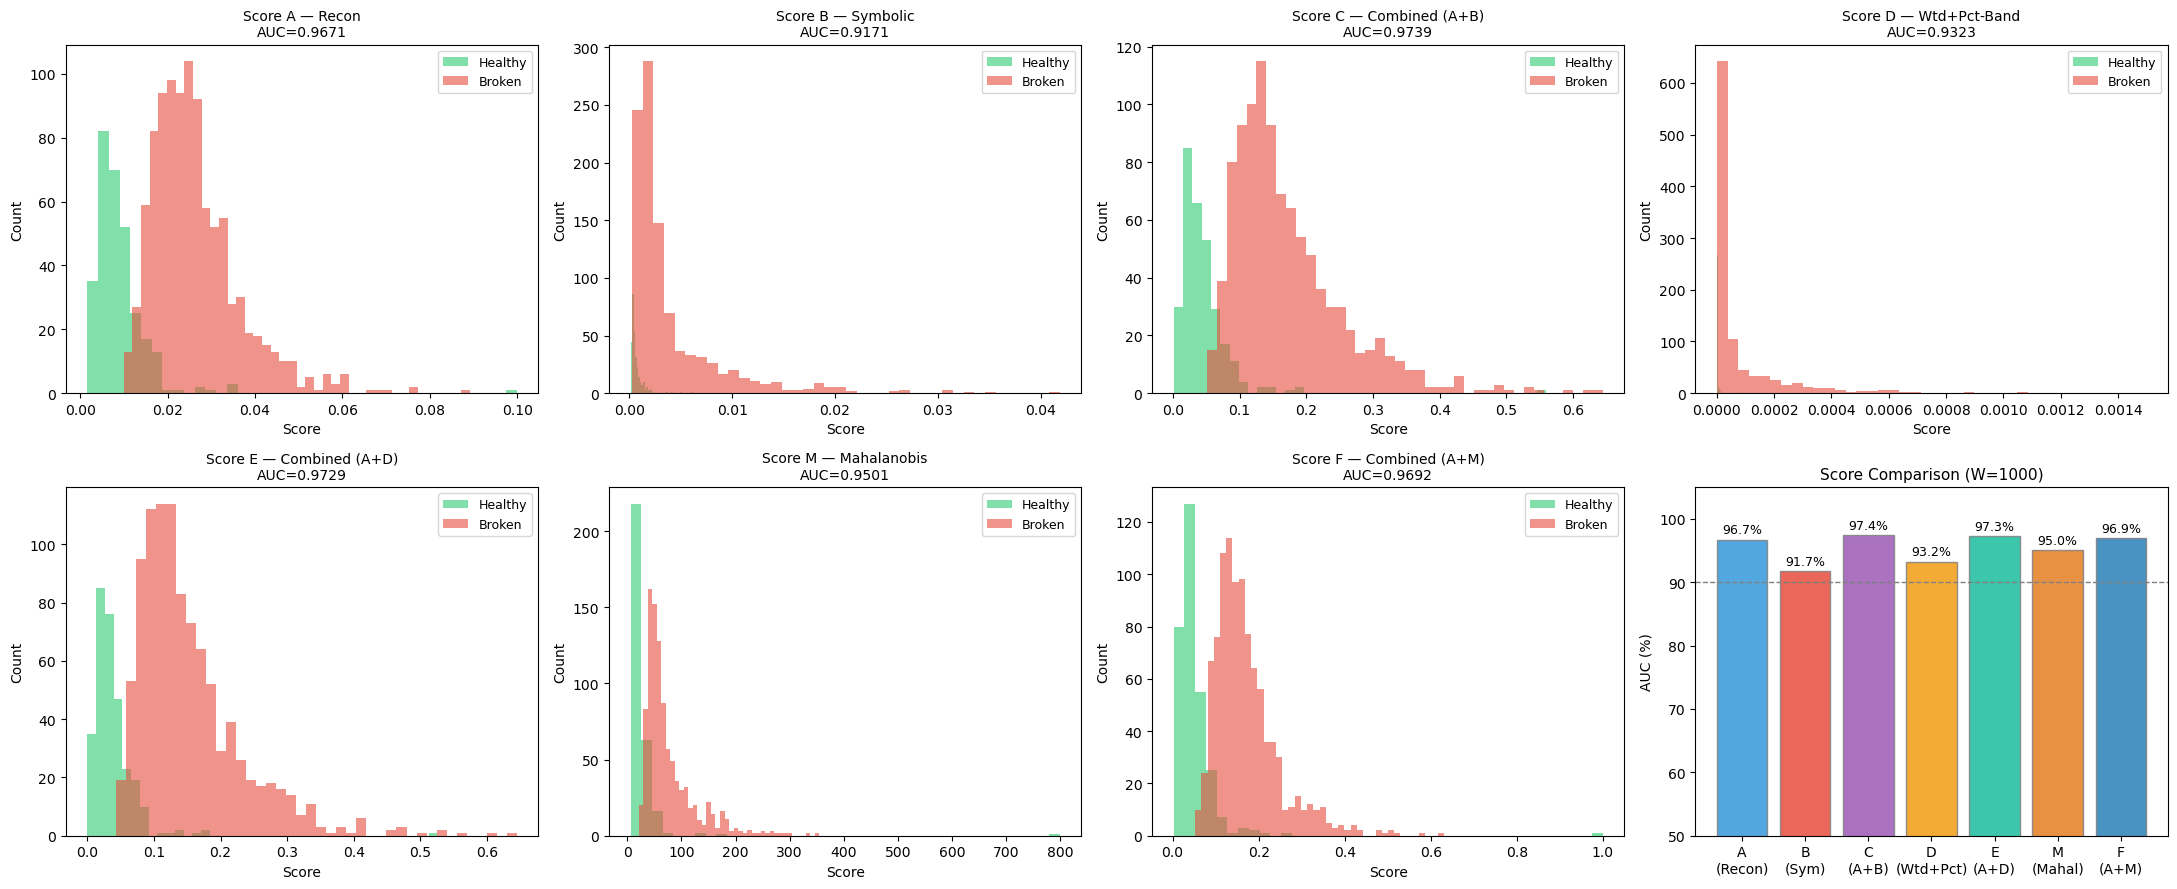

In [16]:
def minmax_norm(arr):
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo + 1e-12)

score_C = 0.5 * minmax_norm(score_A) + 0.5 * minmax_norm(score_B)
score_E = 0.5 * minmax_norm(score_A) + 0.5 * minmax_norm(score_D)
score_F = 0.5 * minmax_norm(score_A) + 0.5 * minmax_norm(score_M)
auc_C   = roc_auc_score(y_test, score_C)
auc_E   = roc_auc_score(y_test, score_E)
auc_F   = roc_auc_score(y_test, score_F)

print(f"Score A (Reconstruction):             AUC = {auc_A:.4f}")
print(f"Score B (Symbolic):                   AUC = {auc_B:.4f}")
print(f"Score C (Combined A+B):               AUC = {auc_C:.4f}")
print(f"Score D (Weighted+Percentile-Band):   AUC = {auc_D:.4f}")
print(f"Score E (Combined A+D):               AUC = {auc_E:.4f}")
print(f"Score M (Mahalanobis):                AUC = {auc_M:.4f}")
print(f"Score F (Combined A+M):               AUC = {auc_F:.4f}")

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
axes = axes.flatten()

score_info = [
    (score_A, f"Score A — Recon\nAUC={auc_A:.4f}"),
    (score_B, f"Score B — Symbolic\nAUC={auc_B:.4f}"),
    (score_C, f"Score C — Combined (A+B)\nAUC={auc_C:.4f}"),
    (score_D, f"Score D — Wtd+Pct-Band\nAUC={auc_D:.4f}"),
    (score_E, f"Score E — Combined (A+D)\nAUC={auc_E:.4f}"),
    (score_M, f"Score M — Mahalanobis\nAUC={auc_M:.4f}"),
    (score_F, f"Score F — Combined (A+M)\nAUC={auc_F:.4f}"),
]
for ax, (sc, title) in zip(axes[:7], score_info):
    ax.hist(sc[y_test==0], bins=40, alpha=0.6, label="Healthy", color="#2ecc71")
    ax.hist(sc[y_test==1], bins=40, alpha=0.6, label="Broken",  color="#e74c3c")
    ax.set_title(title, fontsize=10); ax.legend(fontsize=9)
    ax.set_xlabel("Score"); ax.set_ylabel("Count")

# 8th panel: AUC bar chart comparison
auc_vals = [auc_A, auc_B, auc_C, auc_D, auc_E, auc_M, auc_F]
labels   = ["A\n(Recon)", "B\n(Sym)", "C\n(A+B)", "D\n(Wtd+Pct)", "E\n(A+D)", "M\n(Mahal)", "F\n(A+M)"]
colors   = ["#3498db", "#e74c3c", "#9b59b6", "#f39c12", "#1abc9c", "#e67e22", "#2980b9"]
ax8 = axes[7]
bars = ax8.bar(labels, [v*100 for v in auc_vals], color=colors, alpha=0.85, edgecolor="grey")
ax8.set_ylabel("AUC (%)", fontsize=10)
ax8.set_title("Score Comparison (W=1000)", fontsize=11)
ax8.set_ylim(50, 105)
ax8.axhline(90, color="gray", linestyle="--", linewidth=1)
for bar, v in zip(bars, auc_vals):
    ax8.text(bar.get_x() + bar.get_width()/2, v*100 + 0.5,
             f"{v*100:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "score_distributions.svg"))
plt.show()


## Stage 5b — SHAP Interpretability Baseline

KernelSHAP explains `score_A` (reconstruction error) using 50 faulty test samples.
Global importance = mean |SHAP value| per feature, aggregated across samples.

Building SHAP background (k-means 50 centroids from training data)...


Computing SHAP values for 50 faulty samples (may take ~5-15 min on CPU)...



Top-10 features by SHAP importance:
   feature  shap_importance
    S1_std         0.005271
    S1_rms         0.005240
   S4_mean         0.003342
    S1_p2p         0.002433
  S4_shape         0.001441
   S4_kurt         0.001108
 S4_margin         0.000719
S4_impulse         0.000715
  S1_shape         0.000658
   S3_skew         0.000648


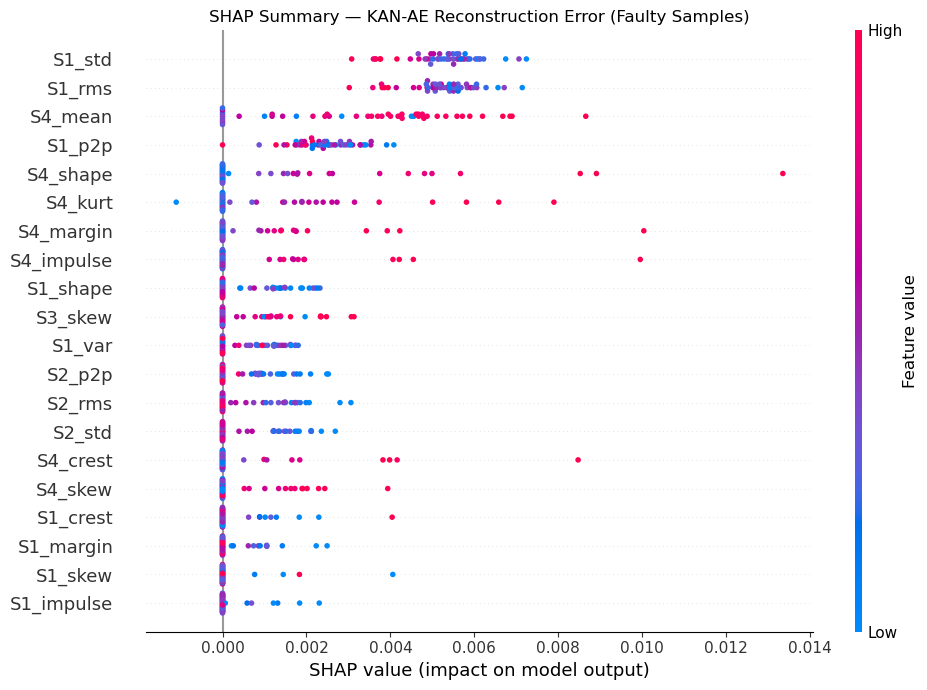

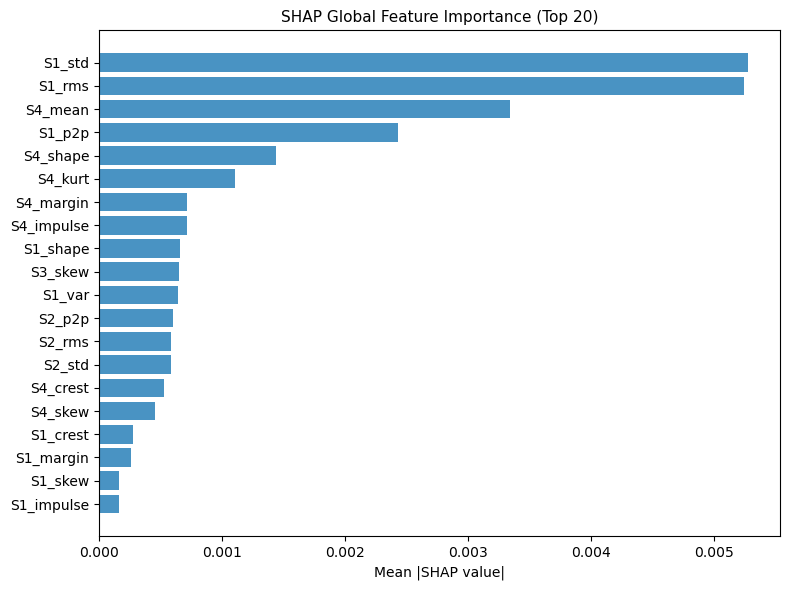

SHAP analysis complete.


In [17]:
# Remove user-level site-packages that conflict with conda env packages
import sys
sys.path = [p for p in sys.path if not p.startswith("/home/suleiman/.local/lib")]

import shap
import lime
from lime import lime_tabular

# ── SHAP: KernelExplainer on reconstruction score ───────────────────────
def predict_score_a(X):
    """Wraps KAN-AE reconstruction error as a callable for model-agnostic explainers."""
    X_t = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        recon = kan_ae(X_t).numpy()
    return np.mean((X - recon) ** 2, axis=1)

# Background: summarise healthy training data with k-means (fast for 44 features)
print("Building SHAP background (k-means 50 centroids from training data)...")
shap_background = shap.kmeans(X_train_np, 50)
explainer_shap  = shap.KernelExplainer(predict_score_a, shap_background)

# Explain 50 faulty samples (most anomalous by Score D for representativeness)
fault_idx         = np.where(y_test == 1)[0]
top_fault_by_D    = fault_idx[np.argsort(score_D[fault_idx])[::-1][:50]]
X_fault_shap      = X_test_np[top_fault_by_D]   # (50, 44)

print("Computing SHAP values for 50 faulty samples (may take ~5-15 min on CPU)...")
shap_values = explainer_shap.shap_values(X_fault_shap, silent=True)  # (50, 44)

# Global feature importance
shap_global = np.abs(shap_values).mean(axis=0)  # (44,)
shap_importance_df = pd.DataFrame({'feature': feat_cols, 'shap_importance': shap_global})\
                       .sort_values('shap_importance', ascending=False).reset_index(drop=True)
print("\nTop-10 features by SHAP importance:")
print(shap_importance_df.head(10).to_string(index=False))

# ── Plot 1: SHAP beeswarm summary ────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_fault_shap,
    feature_names=feat_cols, plot_type='dot',
    show=False, plot_size=None
)
plt.title('SHAP Summary — KAN-AE Reconstruction Error (Faulty Samples)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'shap_beeswarm.svg'), bbox_inches='tight')
plt.show()

# ── Plot 2: SHAP global bar chart (top 20) ───────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 6))
top20_shap = shap_importance_df.head(20)
ax2.barh(top20_shap['feature'][::-1], top20_shap['shap_importance'][::-1],
         color='#2980b9', alpha=0.85)
ax2.set_xlabel('Mean |SHAP value|', fontsize=10)
ax2.set_title('SHAP Global Feature Importance (Top 20)', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'shap_bar.svg'), bbox_inches='tight')
plt.show()

shap_importance_df.to_csv(os.path.join(RESULTS_DIR, 'shap_importance.csv'), index=False)
print('SHAP analysis complete.')


## Stage 5c — LIME Interpretability Baseline

LIME fits a local linear model around each anomaly to explain `score_A`.
Global importance = mean |coefficient| across 50 faulty samples.

Computing LIME explanations for 50 faulty samples...


  10/50 done


  20/50 done


  30/50 done


  40/50 done


  50/50 done

Top-10 features by LIME importance:
   feature  lime_importance
    S3_rms         0.002266
    S3_std         0.002208
    S4_std         0.001545
    S3_var         0.001461
    S4_rms         0.001352
  S4_crest         0.001113
S4_impulse         0.001081
   S4_kurt         0.001034
  S3_shape         0.001033
  S4_shape         0.001021


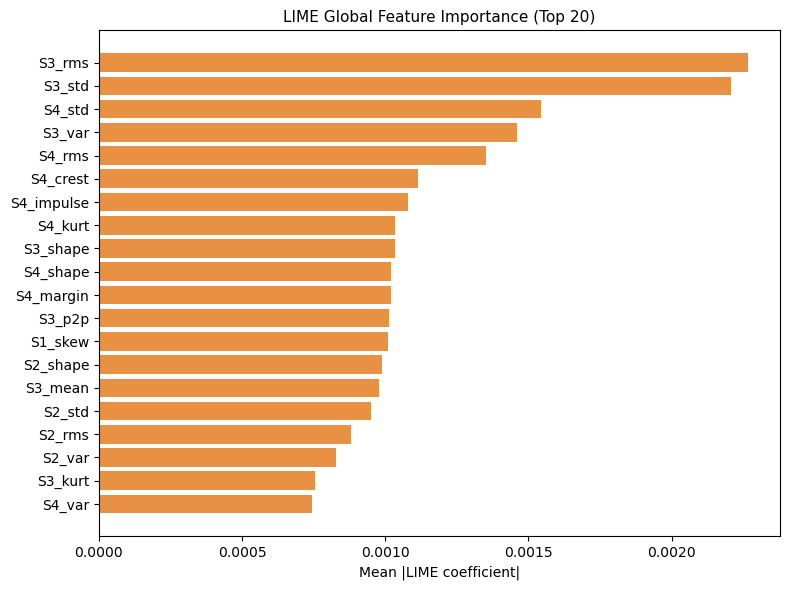

LIME analysis complete.


In [18]:
# ── LIME: LimeTabularExplainer on reconstruction score ──────────────────
lime_explainer = lime_tabular.LimeTabularExplainer(
    X_train_np,
    feature_names=feat_cols,
    mode='regression',
    random_state=SEED
)

print('Computing LIME explanations for 50 faulty samples...')
lime_coefs = np.zeros((len(X_fault_shap), len(feat_cols)))   # (50, 44)
for i, x_sample in enumerate(X_fault_shap):
    exp = lime_explainer.explain_instance(
        x_sample, predict_score_a, num_features=len(feat_cols)
    )
    # exp.as_map() returns {0: [(feat_idx, coef), ...]}
    for feat_idx, coef in exp.as_map()[1]:   # regression target=1
        lime_coefs[i, feat_idx] = abs(coef)
    if (i + 1) % 10 == 0:
        print(f'  {i+1}/50 done')

# Global importance
lime_global = lime_coefs.mean(axis=0)  # (44,)
lime_importance_df = pd.DataFrame({'feature': feat_cols, 'lime_importance': lime_global})\
                      .sort_values('lime_importance', ascending=False).reset_index(drop=True)
print('\nTop-10 features by LIME importance:')
print(lime_importance_df.head(10).to_string(index=False))

# ── Plot: LIME global bar chart (top 20) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
top20_lime = lime_importance_df.head(20)
ax.barh(top20_lime['feature'][::-1], top20_lime['lime_importance'][::-1],
        color='#e67e22', alpha=0.85)
ax.set_xlabel('Mean |LIME coefficient|', fontsize=10)
ax.set_title('LIME Global Feature Importance (Top 20)', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'lime_bar.svg'), bbox_inches='tight')
plt.show()

lime_importance_df.to_csv(os.path.join(RESULTS_DIR, 'lime_importance.csv'), index=False)
print('LIME analysis complete.')


## Stage 6 — Full Benchmark: 9 Baselines + SHAP/LIME + 7 KAN-AE Scores

**18 methods × 8 window sizes** AUC table.

- The 9 classic unsupervised detectors (IsolationForest, OC-SVM, LOF, PatchCore, Autoencoder, VAE, DeepSVDD, TeacherStudent, SSL_DAE) are re-trained from scratch for each window size using `StandardScaler`.
- **SHAP-Weighted-Recon** and **LIME-Weighted-Recon** use feature importance weights derived from Stages 5b/5c applied to the KAN-AE reconstruction error, providing explainability-guided anomaly scores.
- The 7 KAN-AE scores use the **single W=1000 model** evaluated across all windows (cross-window generalisation). The W=1000 `MinMaxScaler` is applied to other-window data — values may fall slightly outside [0,1] for small windows, which is expected and mirrors realistic deployment.
- **Score D** = R²-weighted + tolerance-band symbolic violation; **Score E** = 0.5·minmax(A) + 0.5·minmax(D).


In [19]:
# ── Deep-learning baseline architectures ─────────────────────────────────
class AE(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.e = nn.Sequential(nn.Linear(d,32), nn.ReLU(), nn.Linear(32,16), nn.ReLU(), nn.Linear(16,8), nn.ReLU())
        self.d = nn.Sequential(nn.Linear(8,16), nn.ReLU(), nn.Linear(16,32), nn.ReLU(), nn.Linear(32,d))
    def forward(self, x): return self.d(self.e(x))

class VAENet(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.e   = nn.Sequential(nn.Linear(d,32), nn.ReLU(), nn.Linear(32,16), nn.ReLU())
        self.mu  = nn.Linear(16,8); self.var = nn.Linear(16,8)
        self.d   = nn.Sequential(nn.Linear(8,16), nn.ReLU(), nn.Linear(16,32), nn.ReLU(), nn.Linear(32,d))
    def forward(self, x):
        h = self.e(x); m, lv = self.mu(h), self.var(h)
        return self.d(m + torch.randn_like(torch.exp(0.5*lv)) * torch.exp(0.5*lv)), m, lv

class DeepSVDD(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.n = nn.Sequential(nn.Linear(d,32), nn.ReLU(), nn.Linear(32,16), nn.ReLU(), nn.Linear(16,16))
    def forward(self, x): return self.n(x)

class TSNetwork(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.n = nn.Sequential(nn.Linear(d,32), nn.ReLU(), nn.Linear(32,16))
    def forward(self, x): return self.n(x)

class DAE(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.e = nn.Sequential(nn.Linear(d,32), nn.ReLU(), nn.Linear(32,8))
        self.d = nn.Sequential(nn.Linear(8,32), nn.ReLU(), nn.Linear(32,d))
    def forward(self, x): return self.d(self.e(x))

def k_center(f, frac=0.1):
    c = [np.random.randint(0, f.shape[0])]
    dists = pairwise_distances(f, f[c], metric='euclidean').flatten()
    for _ in range(max(1, int(f.shape[0]*frac)) - 1):
        idx = np.argmax(dists); c.append(idx)
        dists = np.minimum(dists, pairwise_distances(f, f[[idx]]).flatten())
    return f[c]

def run_baseline_detectors(windows=WINDOWS):
    names = ["IsolationForest","OC-SVM","LOF","PatchCore",
             "Autoencoder","VAE","DeepSVDD","TeacherStudent","SSL_DAE"]
    res = pd.DataFrame(index=names, columns=windows, dtype=float)
    for W in windows:
        df   = pd.read_csv(os.path.join(PROCESSED_DIR, f"features_W{W}.csv"))
        fc   = [c for c in df.columns if c not in ['load','label']]
        tr,te = train_test_split(df[df['label']==0], test_size=0.3, random_state=SEED)
        te    = pd.concat([te, df[df['label']==1]])
        sc    = StandardScaler().fit(tr[fc].values)
        X_tr, X_te = sc.transform(tr[fc].values), sc.transform(te[fc].values)
        y_te  = te['label'].values
        res.loc["IsolationForest",W] = roc_auc_score(y_te,
            -IsolationForest(n_estimators=100,random_state=SEED).fit(X_tr).decision_function(X_te))
        res.loc["OC-SVM",W] = roc_auc_score(y_te,
            -OneClassSVM(kernel="rbf",gamma="scale",nu=0.05).fit(X_tr).decision_function(X_te))
        res.loc["LOF",W] = roc_auc_score(y_te,
            -LocalOutlierFactor(n_neighbors=20,novelty=True).fit(X_tr).decision_function(X_te))
        res.loc["PatchCore",W] = roc_auc_score(y_te,
            pairwise_distances(X_te, k_center(X_tr), metric='euclidean').min(axis=1))
        Xtr_t = torch.tensor(X_tr,dtype=torch.float32)
        Xte_t = torch.tensor(X_te,dtype=torch.float32)
        ldr   = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(Xtr_t,Xtr_t), batch_size=256, shuffle=True)
        d = len(fc)
        ae_b = AE(d); o=torch.optim.Adam(ae_b.parameters(),lr=1e-3)
        for _ in range(15):
            for b,_ in ldr: o.zero_grad(); nn.MSELoss()(ae_b(b),b).backward(); o.step()
        with torch.no_grad(): res.loc["Autoencoder",W]=roc_auc_score(y_te,
            torch.mean((ae_b(Xte_t)-Xte_t)**2,dim=1).cpu())
        vae_b = VAENet(d); o=torch.optim.Adam(vae_b.parameters(),lr=1e-3)
        for _ in range(15):
            for b,_ in ldr:
                o.zero_grad(); x,m,lv=vae_b(b)
                (nn.MSELoss()(x,b)-0.0005*torch.sum(1+lv-m.pow(2)-lv.exp())).backward(); o.step()
        with torch.no_grad(): res.loc["VAE",W]=roc_auc_score(y_te,
            torch.mean((vae_b(Xte_t)[0]-Xte_t)**2,dim=1).cpu())
        svdd = DeepSVDD(d); o=torch.optim.Adam(svdd.parameters(),lr=1e-3)
        with torch.no_grad(): c_svdd=torch.mean(svdd(Xtr_t),dim=0)
        for _ in range(15):
            for b,_ in ldr:
                o.zero_grad(); torch.mean(torch.sum((svdd(b)-c_svdd)**2,dim=1)).backward(); o.step()
        with torch.no_grad(): res.loc["DeepSVDD",W]=roc_auc_score(y_te,
            torch.sum((svdd(Xte_t)-c_svdd)**2,dim=1).cpu())
        t_net=TSNetwork(d); s_net=TSNetwork(d); o=torch.optim.Adam(s_net.parameters(),lr=1e-3)
        for p in t_net.parameters(): p.requires_grad=False
        for _ in range(15):
            for b,_ in ldr: o.zero_grad(); nn.MSELoss()(s_net(b),t_net(b)).backward(); o.step()
        with torch.no_grad(): res.loc["TeacherStudent",W]=roc_auc_score(y_te,
            torch.mean((s_net(Xte_t)-t_net(Xte_t))**2,dim=1).cpu())
        dae_b = DAE(d); o=torch.optim.Adam(dae_b.parameters(),lr=1e-3)
        for _ in range(15):
            for b,_ in ldr:
                o.zero_grad(); nn.MSELoss()(dae_b(b+0.5*torch.randn_like(b)),b).backward(); o.step()
        with torch.no_grad(): res.loc["SSL_DAE",W]=roc_auc_score(y_te,
            torch.mean((dae_b(Xte_t)-Xte_t)**2,dim=1).cpu())
        print(f"  W={W} baselines done.")
    return res

def run_kan_ae_scores(windows=WINDOWS):
    rows = ["KAN-AE-Recon","KAN-AE-Symbolic","KAN-AE-Combined",
            "KAN-AE-Symbolic-D","KAN-AE-Combined-E","KAN-AE-Mahal",
            "KAN-AE-Combined-F","KAN-AE-SymRecon"]
    res  = pd.DataFrame(index=rows, columns=windows, dtype=float)
    kan_ae.eval(); kan_ae.cpu()
    for W in windows:
        df_w = pd.read_csv(os.path.join(PROCESSED_DIR, f"features_W{W}.csv"))
        fc   = [c for c in df_w.columns if c not in ['load','label']]
        _,te_h = train_test_split(df_w[df_w['label']==0], test_size=0.3, random_state=SEED)
        te_w  = pd.concat([te_h, df_w[df_w['label']==1]]).reset_index(drop=True)
        y_w   = te_w['label'].values
        X_te_w = scaler_test.transform(te_w[fc].values).astype(np.float32)
        Xte_t  = torch.tensor(X_te_w, dtype=torch.float32)
        with torch.no_grad():
            recon_w = kan_ae(Xte_t).numpy()
            h1_w    = kan_ae.layers[0](Xte_t).numpy()
        sA = ((X_te_w - recon_w)**2).mean(axis=1)

        # Calibrated symbolic prediction of h1
        raw_w = np.zeros((len(te_w), 22), dtype=np.float64)
        for _, row in sym_df.iterrows():
            j2 = int(row["out_neuron"]); i2 = int(row["in_feat_idx"])
            if i2 >= X_te_w.shape[1]: continue
            try: raw_w[:, j2] += CANDIDATES_DICT[row["best_symbol"]](
                    X_te_w[:, i2].astype(np.float64), *row["params"])
            except Exception: pass
        sp = (raw_w * eq_scale_l0 + eq_bias_l0).astype(np.float32)

        raw_res_w  = h1_w - sp
        sB         = (raw_res_w ** 2).sum(axis=1)
        deadband_w = (np.maximum(0.0, raw_res_w - band_hi) +
              np.maximum(0.0, band_lo - raw_res_w))
        sD         = (eq_weights * deadband_w ** 2).sum(axis=1)
        r_c_w      = raw_res_w - resid_mean
        sM         = np.array([r @ inv_cov @ r for r in r_c_w])

        # Score SR — full symbolic reconstruction
        _, _, _, x_rec_sym_w = symbolic_forward(X_te_w)
        sSR = ((X_te_w - x_rec_sym_w.astype(np.float32)) ** 2).mean(axis=1)

        def _n(a):
            lo,hi=a.min(),a.max(); return (a-lo)/(hi-lo+1e-12)
        sC = 0.5*_n(sA) + 0.5*_n(sB)
        sE = 0.5*_n(sA) + 0.5*_n(sD)
        sF = 0.5*_n(sA) + 0.5*_n(sM)
        res.loc["KAN-AE-Recon",      W] = roc_auc_score(y_w, sA)
        res.loc["KAN-AE-Symbolic",   W] = roc_auc_score(y_w, sB)
        res.loc["KAN-AE-Combined",   W] = roc_auc_score(y_w, sC)
        res.loc["KAN-AE-Symbolic-D", W] = roc_auc_score(y_w, sD)
        res.loc["KAN-AE-Combined-E", W] = roc_auc_score(y_w, sE)
        res.loc["KAN-AE-Mahal",      W] = roc_auc_score(y_w, sM)
        res.loc["KAN-AE-Combined-F", W] = roc_auc_score(y_w, sF)
        res.loc["KAN-AE-SymRecon",   W] = roc_auc_score(y_w, sSR)
        print(f"  W={W}: A={res.loc['KAN-AE-Recon',W]:.3f} "
              f"B={res.loc['KAN-AE-Symbolic',W]:.3f} D={res.loc['KAN-AE-Symbolic-D',W]:.3f} "
              f"M={res.loc['KAN-AE-Mahal',W]:.3f} F={res.loc['KAN-AE-Combined-F',W]:.3f} "
              f"SR={res.loc['KAN-AE-SymRecon',W]:.3f}")
    return res

def run_shap_lime_scores(windows=WINDOWS):
    """SHAP-weighted and LIME-weighted reconstruction anomaly scores.
    
    Uses globally computed shap_global / lime_global (mean |attribution|
    per feature from Stage 5b/5c) as a feature-importance weighting of
    the KAN-AE per-feature squared reconstruction error.
    
    score_SHAP(x) = Σ_i  w_SHAP[i] · (x_i − x̂_i)²
    score_LIME(x) = Σ_i  w_LIME[i] · (x_i − x̂_i)²
    """
    shap_w = shap_global / (shap_global.sum() + 1e-12)   # (44,) normalised
    lime_w = lime_global / (lime_global.sum() + 1e-12)   # (44,) normalised

    rows = ["SHAP-Weighted-Recon", "LIME-Weighted-Recon"]
    res  = pd.DataFrame(index=rows, columns=windows, dtype=float)
    kan_ae.eval(); kan_ae.cpu()

    for W in windows:
        df_w = pd.read_csv(os.path.join(PROCESSED_DIR, f"features_W{W}.csv"))
        fc   = [c for c in df_w.columns if c not in ['load','label']]
        _, te_h = train_test_split(df_w[df_w['label']==0], test_size=0.3, random_state=SEED)
        te_w    = pd.concat([te_h, df_w[df_w['label']==1]]).reset_index(drop=True)
        y_w     = te_w['label'].values
        X_te_w  = scaler_test.transform(te_w[fc].values).astype(np.float32)
        Xte_t   = torch.tensor(X_te_w, dtype=torch.float32)
        with torch.no_grad():
            recon_w = kan_ae(Xte_t).numpy()
        sq_err           = (X_te_w - recon_w) ** 2                  # (n, 44)
        score_shap_w     = (shap_w * sq_err).sum(axis=1)
        score_lime_w     = (lime_w * sq_err).sum(axis=1)
        res.loc["SHAP-Weighted-Recon", W] = roc_auc_score(y_w, score_shap_w)
        res.loc["LIME-Weighted-Recon", W] = roc_auc_score(y_w, score_lime_w)
        print(f"  W={W}: SHAP-Recon={res.loc['SHAP-Weighted-Recon',W]:.3f}  "
              f"LIME-Recon={res.loc['LIME-Weighted-Recon',W]:.3f}")
    return res

print("Benchmark functions defined (9 baselines + SHAP/LIME + 7 KAN-AE scores = 18 methods).")


Benchmark functions defined (9 baselines + SHAP/LIME + 7 KAN-AE scores = 18 methods).


In [20]:
print("Running 9 baseline detectors across 8 window sizes (~5-15 min on CPU)...")
baseline_res = run_baseline_detectors()

print("\nRunning SHAP-weighted and LIME-weighted anomaly scores across 8 window sizes...")
shap_lime_res = run_shap_lime_scores()

print("\nRunning KAN-AE scores across 8 window sizes...")
kan_res = run_kan_ae_scores()

full_bench     = pd.concat([baseline_res, shap_lime_res, kan_res])
full_bench_pct = (full_bench * 100).round(2)

print("\nAUC (%) — All 18 Methods × 8 Window Sizes:")
display(full_bench_pct)
full_bench.to_csv(os.path.join(RESULTS_DIR, "benchmark_auc.csv"))

# Print SHAP and LIME summary
print("\nSHAP-Weighted-Recon AUC across windows:")
for W in WINDOWS:
    print(f"  W={W}: {full_bench.loc['SHAP-Weighted-Recon',W]*100:.2f}%")
print("LIME-Weighted-Recon AUC across windows:")
for W in WINDOWS:
    print(f"  W={W}: {full_bench.loc['LIME-Weighted-Recon',W]*100:.2f}%")

# Best method per window
best_per_w = full_bench.idxmax(axis=0)
print("\nBest method per window:")
for W in WINDOWS:
    print(f"  W={W:4d}: {best_per_w[W]:25s}  AUC={full_bench.loc[best_per_w[W],W]*100:.2f}%")


Running 9 baseline detectors across 8 window sizes (~5-15 min on CPU)...


  W=300 baselines done.


  W=400 baselines done.


  W=500 baselines done.


  W=600 baselines done.


...

  W=800: A=0.958 B=0.901 D=0.910 M=0.928 F=0.959 SR=0.955


  W=900: A=0.974 B=0.910 D=0.925 M=0.959 F=0.976 SR=0.972


  W=1000: A=0.967 B=0.917 D=0.932 M=0.950 F=0.969 SR=0.965

AUC (%) — All 18 Methods × 8 Window Sizes:


,300,400,500,600,700,800,900,1000
IsolationForest,60.26,73.52,69.15,76.95,82.33,85.65,86.04,86.99
OC-SVM,77.22,82.07,87.91,88.89,94.12,96.55,98.88,98.25
LOF,88.15,91.15,92.96,94.04,95.96,97.74,99.40,99.28
PatchCore,77.67,82.91,86.12,87.40,92.38,92.98,95.93,97.97
Autoencoder,70.28,73.87,80.55,79.75,85.48,89.99,93.00,91.15
VAE,59.46,64.36,65.28,69.63,76.67,79.43,82.67,84.74
DeepSVDD,76.46,60.00,78.14,65.18,71.53,75.31,79.75,89.34
TeacherStudent,83.55,75.41,83.65,86.57,91.21,97.54,92.55,92.92
SSL_DAE,76.96,74.41,81.36,82.92,90.51,90.15,92.59,95.17
SHAP-Weighted-Recon,93.96,95.29,96.88,97.75,98.18,99.70,99.78,99.49



SHAP-Weighted-Recon AUC across windows:
  W=300: 93.96%
  W=400: 95.29%
  W=500: 96.88%
  W=600: 97.75%
  W=700: 98.18%
  W=800: 99.70%
  W=900: 99.78%
  W=1000: 99.49%
LIME-Weighted-Recon AUC across windows:
  W=300: 69.18%
  W=400: 77.11%
  W=500: 80.70%
  W=600: 85.25%
  W=700: 88.39%
  W=800: 91.66%
  W=900: 93.64%
  W=1000: 93.48%

Best method per window:
  W= 300: SHAP-Weighted-Recon        AUC=93.96%
  W= 400: SHAP-Weighted-Recon        AUC=95.29%
  W= 500: SHAP-Weighted-Recon        AUC=96.88%
  W= 600: SHAP-Weighted-Recon        AUC=97.75%
  W= 700: SHAP-Weighted-Recon        AUC=98.18%
  W= 800: SHAP-Weighted-Recon        AUC=99.70%
  W= 900: SHAP-Weighted-Recon        AUC=99.78%
  W=1000: SHAP-Weighted-Recon        AUC=99.49%


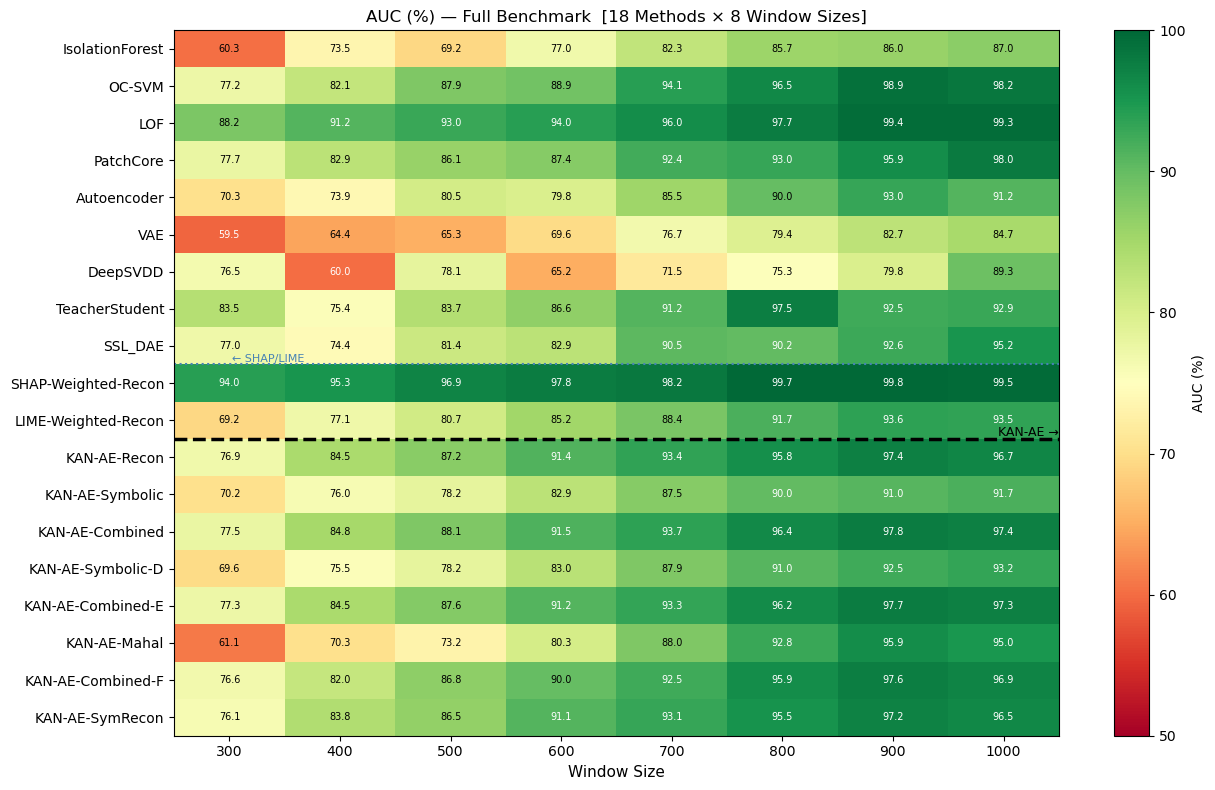

In [21]:
fig, ax = plt.subplots(figsize=(13, 8))
vals = full_bench_pct.values.astype(float)
im   = ax.imshow(vals, aspect='auto', cmap='RdYlGn', vmin=50, vmax=100)

ax.set_xticks(range(len(WINDOWS))); ax.set_xticklabels(WINDOWS, fontsize=10)
ax.set_yticks(range(len(full_bench))); ax.set_yticklabels(full_bench.index, fontsize=10)
ax.set_xlabel("Window Size", fontsize=11)
ax.set_title("AUC (%) — Full Benchmark  [18 Methods × 8 Window Sizes]", fontsize=12)

# Annotate cells
for i in range(len(full_bench)):
    for j in range(len(WINDOWS)):
        v = vals[i, j]
        ax.text(j, i, f"{v:.1f}", ha='center', va='center', fontsize=7,
                color='black' if 60 < v < 90 else 'white')

# Separator between 9 baselines + SHAP/LIME and 7 KAN-AE rows
ax.axhline(8.5, color='steelblue', linewidth=1.5, linestyle=':')   # SHAP/LIME boundary
ax.text(0.02, 8.5, '← SHAP/LIME', va='bottom', ha='left', fontsize=8, color='steelblue')
ax.axhline(10.5, color='black', linewidth=2.5, linestyle='--')     # KAN-AE boundary
ax.text(len(WINDOWS) - 0.5, 10.5, ' KAN-AE →', va='bottom', ha='right',
        fontsize=9, color='black')

plt.colorbar(im, ax=ax, label='AUC (%)')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "benchmark_heatmap.svg"), bbox_inches='tight')
plt.show()


## Stage 7 — Fault Localization via Equation Violation

`sym_residuals` has shape `(n_test, 22)` — one violation score per encoder equation. By comparing healthy vs broken residuals per equation, we identify which equations (and therefore which input features) are most disrupted by the fault.  

Since each equation involves specific sensor features, a violation pattern directly maps to physical sensor channels — **unsupervised fault attribution**, no fault labels used.

Top 10 most violated equations in broken samples:
Rank      Eq   Fault Ratio  Features involved
-----------------------------------------------------------------
   1    z_06        16.19x   S1_mean, S1_rms, S1_std, S1_var...
                            → sensors: ['S1', 'S2', 'S3', 'S4']
   2    z_19         5.88x   S1_mean, S1_rms, S1_var, S1_kurt...
                            → sensors: ['S1', 'S2', 'S3', 'S4']
   3    z_21         3.90x   S1_mean, S1_var, S1_skew, S1_kurt...
                            → sensors: ['S1', 'S2', 'S3', 'S4']
   4    z_09         3.76x   S1_rms, S1_std, S1_var, S1_skew...
                            → sensors: ['S1', 'S2', 'S3', 'S4']
   5    z_15         3.56x   S1_rms, S1_std, S1_var, S1_skew...
                            → sensors: ['S1', 'S2', 'S3', 'S4']
   6    z_16         3.04x   S1_rms, S1_var, S1_skew, S1_kurt...
                            → sensors: ['S1', 'S2', 'S3', 'S4']
   7    z_13         2.56x   S1_mean, S1_rms, S1_var, S1_skew...
 

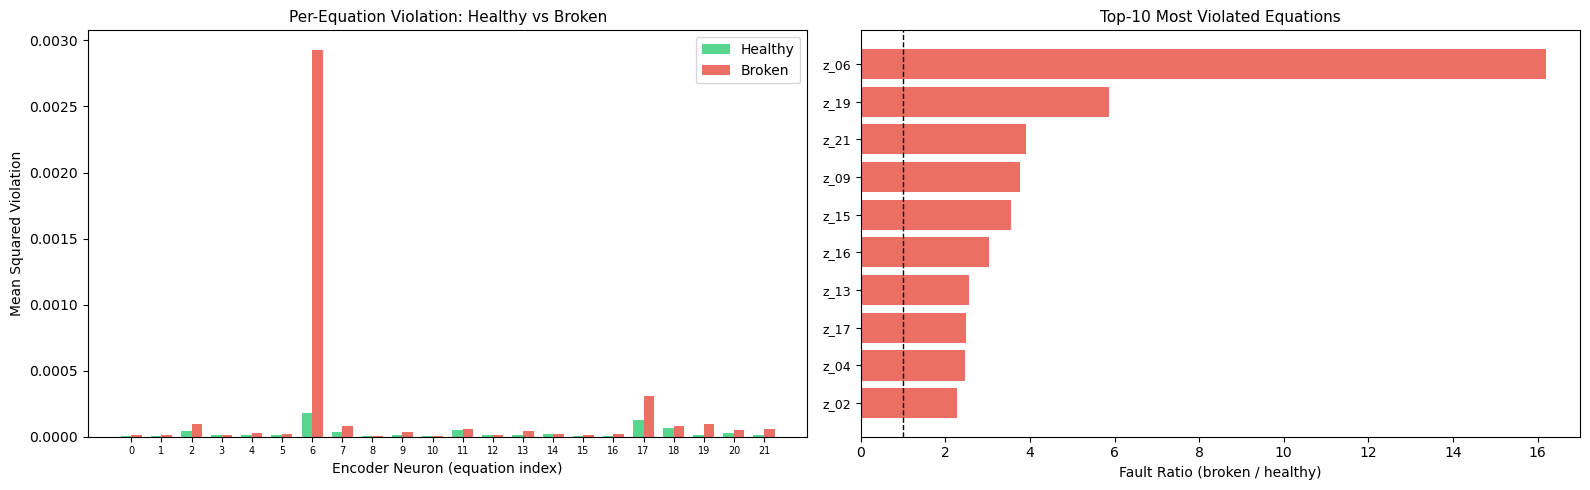

In [22]:
healthy_mask = (y_test == 0)
broken_mask  = (y_test == 1)

mean_viol_healthy = sym_residuals[healthy_mask].mean(axis=0)   # (22,)
mean_viol_broken  = sym_residuals[broken_mask].mean(axis=0)    # (22,)
fault_ratio       = mean_viol_broken / (mean_viol_healthy + 1e-12)  # (22,)

top_k = 10
top_violated = np.argsort(fault_ratio)[::-1][:top_k]

print(f"Top {top_k} most violated equations in broken samples:")
print(f"{'Rank':>4}  {'Eq':>6}  {'Fault Ratio':>12}  {'Features involved'}")
print("-" * 65)
for rank, eq_idx in enumerate(top_violated, 1):
    feeding = sym_df[sym_df["out_neuron"] == eq_idx]["in_feature"].tolist()
    sensors = sorted(set(f.split("_")[0] for f in feeding))
    print(f"  {rank:2d}    z_{eq_idx:02d}   {fault_ratio[eq_idx]:>10.2f}x   "
          f"{', '.join(feeding[:4])}{'...' if len(feeding)>4 else ''}")
    print(f"                            → sensors: {sensors}")

# 2-panel bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x_pos = np.arange(22); w = 0.35
axes[0].bar(x_pos-w/2, mean_viol_healthy, w, color='#2ecc71', alpha=0.8, label='Healthy')
axes[0].bar(x_pos+w/2, mean_viol_broken,  w, color='#e74c3c', alpha=0.8, label='Broken')
axes[0].set_xlabel("Encoder Neuron (equation index)", fontsize=10)
axes[0].set_ylabel("Mean Squared Violation", fontsize=10)
axes[0].set_title("Per-Equation Violation: Healthy vs Broken", fontsize=11)
axes[0].legend(fontsize=10); axes[0].set_xticks(x_pos); axes[0].set_xticklabels(x_pos, fontsize=7)

top_rev = top_violated[::-1]
axes[1].barh(range(top_k), fault_ratio[top_rev], color='#e74c3c', alpha=0.8)
axes[1].set_yticks(range(top_k))
axes[1].set_yticklabels([f"z_{i:02d}" for i in top_rev], fontsize=9)
axes[1].set_xlabel("Fault Ratio (broken / healthy)", fontsize=10)
axes[1].set_title(f"Top-{top_k} Most Violated Equations", fontsize=11)
axes[1].axvline(1.0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "fault_localization.svg"))
plt.show()

fault_loc_df = pd.DataFrame({
    "equation":    [f"z_{i:02d}" for i in range(22)],
    "mean_healthy": mean_viol_healthy,
    "mean_broken":  mean_viol_broken,
    "fault_ratio":  fault_ratio,
}).sort_values("fault_ratio", ascending=False)
fault_loc_df.to_csv(os.path.join(RESULTS_DIR, "fault_localization.csv"), index=False)


## Stage 7b — SHAP vs LIME vs Score D: Single-Sample Interpretability Comparison

For the single most anomalous sample (highest Score D among faulty test set),
compare feature attributions from SHAP, LIME, and Score D side-by-side.

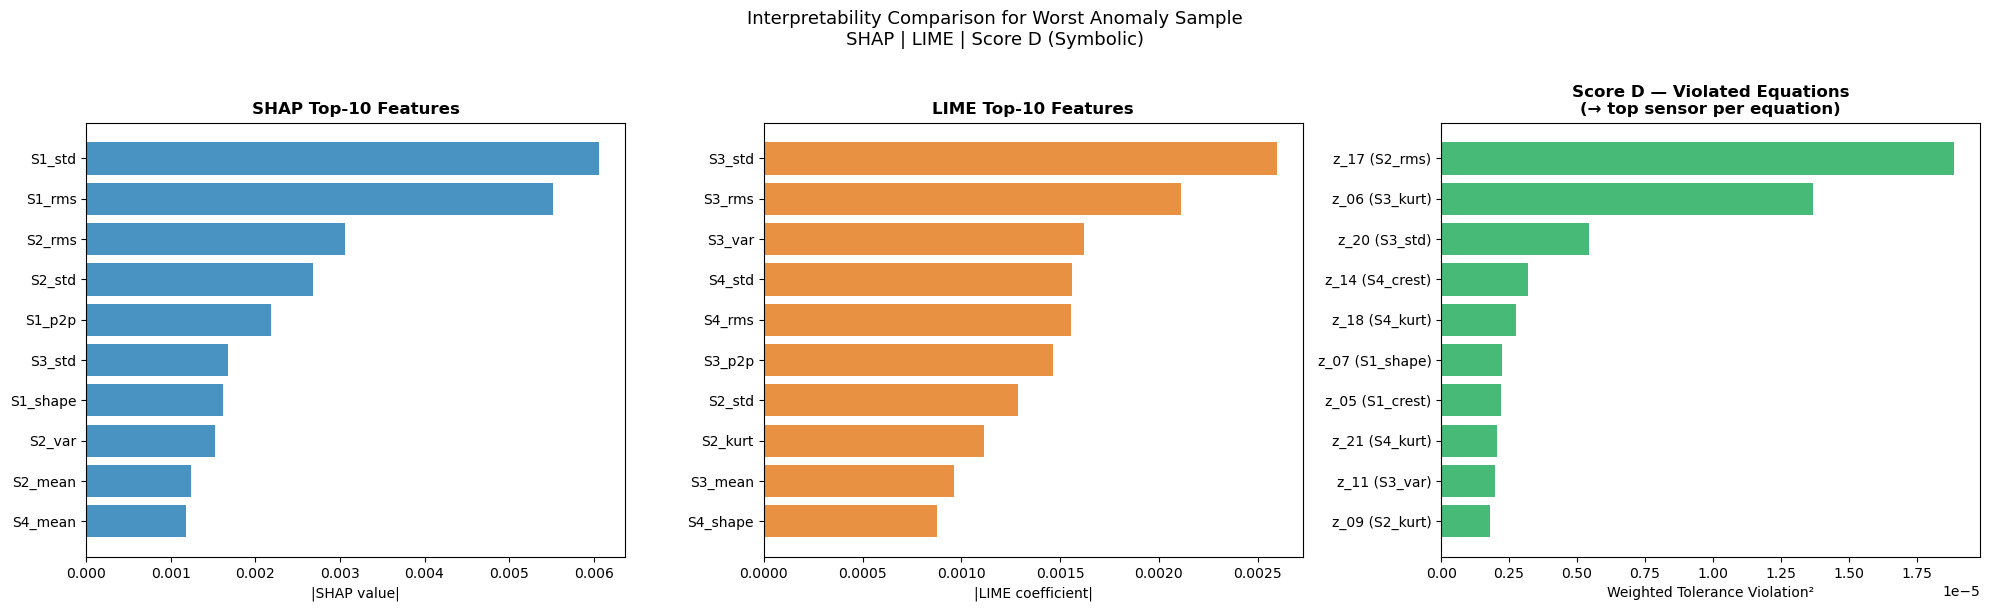


── Feature overlap between interpretability methods ──────────────────
SHAP top-10 ∩ Score-D top-5-eq features: {'S1_std', 'S1_p2p', 'S2_mean', 'S3_std', 'S2_rms', 'S1_rms', 'S2_var', 'S4_mean', 'S2_std', 'S1_shape'}
LIME top-10 ∩ Score-D top-5-eq features: {'S3_mean', 'S4_shape', 'S4_std', 'S3_var', 'S3_std', 'S2_kurt', 'S2_std', 'S4_rms', 'S3_rms', 'S3_p2p'}
SHAP ∩ LIME top-10:                       {'S3_std', 'S2_std'}

Score D additionally provides:
  • Which symbolic health equation failed (equation-level attribution)
  • How far beyond healthy calibration band (tolerance in σ units)
  • R²-weighted equation trust (not available in SHAP/LIME)
  • Deployable without neural network at inference time

── Benchmark AUC comparison at W=1000 ───────────────────────────────
  SHAP-Weighted-Recon             AUC = 99.49%
  KAN-AE-Combined-E               AUC = 97.29%
  KAN-AE-Combined-F               AUC = 96.92%
  LIME-Weighted-Recon             AUC = 93.48%
  KAN-AE-Symbolic-D         

In [23]:
# ── Three-way interpretability comparison for worst anomaly ─────────────
# Identify worst anomaly sample among faulty test set
worst_in_fault = np.argmax(score_D[top_fault_by_D])   # index within X_fault_shap
worst_sample   = X_fault_shap[worst_in_fault]

# --- SHAP for worst sample ---
shap_single = shap_values[worst_in_fault]              # (44,)
shap_df_single = pd.DataFrame({'feature': feat_cols, 'shap_val': np.abs(shap_single)})\
                   .sort_values('shap_val', ascending=False).head(10)

# --- LIME for worst sample ---
lime_exp_single = lime_explainer.explain_instance(
    worst_sample, predict_score_a, num_features=10
)
lime_pairs   = sorted(lime_exp_single.as_map()[1], key=lambda x: abs(x[1]), reverse=True)[:10]
lime_df_single = pd.DataFrame({
    'feature': [feat_cols[i] for i, _ in lime_pairs],
    'lime_val': [abs(v) for _, v in lime_pairs]
})

# --- Score D for worst sample ---
# Get per-equation violation for this sample
worst_global_idx = int(top_fault_by_D[worst_in_fault])          # index in full test set
eq_viol_single   = np.zeros(22)
for j in range(22):
    res_j = abs(h1_np[worst_global_idx, j] - sym_h1_pred[worst_global_idx, j])
    eq_viol_single[j] = eq_weights[j] * np.maximum(0.0, res_j - deadband[worst_global_idx, j]) ** 2

top_eq_idx = np.argsort(eq_viol_single)[::-1][:10]
# Map each violated equation to its top contributing feature
eq_top_features = []
for eq in top_eq_idx:
    edges_for_eq = sym_df[sym_df['out_neuron'] == eq].sort_values('r2', ascending=False)
    top_feat = edges_for_eq['in_feature'].iloc[0] if len(edges_for_eq) > 0 else f'z_{eq:02d}'
    eq_top_features.append(f"z_{eq:02d} ({top_feat})")

scored_df_single = pd.DataFrame({
    'equation_label': eq_top_features,
    'score_d_viol':   eq_viol_single[top_eq_idx]
})

# ── Three-panel comparison plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: SHAP
axes[0].barh(shap_df_single['feature'][::-1], shap_df_single['shap_val'][::-1],
             color='#2980b9', alpha=0.85)
axes[0].set_title('SHAP Top-10 Features', fontsize=12, fontweight='bold')
axes[0].set_xlabel('|SHAP value|', fontsize=10)

# Panel 2: LIME
axes[1].barh(lime_df_single['feature'][::-1], lime_df_single['lime_val'][::-1],
             color='#e67e22', alpha=0.85)
axes[1].set_title('LIME Top-10 Features', fontsize=12, fontweight='bold')
axes[1].set_xlabel('|LIME coefficient|', fontsize=10)

# Panel 3: Score D
axes[2].barh(scored_df_single['equation_label'][::-1], scored_df_single['score_d_viol'][::-1],
             color='#27ae60', alpha=0.85)
axes[2].set_title('Score D — Violated Equations\n(→ top sensor per equation)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Weighted Tolerance Violation²', fontsize=10)

fig.suptitle('Interpretability Comparison for Worst Anomaly Sample\nSHAP | LIME | Score D (Symbolic)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'lime_vs_shap_vs_scoreD.svg'), bbox_inches='tight')
plt.show()

# ── Overlap analysis: do SHAP/LIME top features appear in Score D's violated equations? ──
shap_top10_feats = set(shap_df_single['feature'].tolist())
lime_top10_feats = set(lime_df_single['feature'].tolist())

# Collect all features from top violated equations
score_d_feats = set()
for eq in top_eq_idx[:5]:   # top 5 violated equations
    edges = sym_df[sym_df['out_neuron'] == eq]['in_feature'].tolist()
    score_d_feats.update(edges)

print('\n── Feature overlap between interpretability methods ──────────────────')
print(f'SHAP top-10 ∩ Score-D top-5-eq features: {shap_top10_feats & score_d_feats}')
print(f'LIME top-10 ∩ Score-D top-5-eq features: {lime_top10_feats & score_d_feats}')
print(f'SHAP ∩ LIME top-10:                       {shap_top10_feats & lime_top10_feats}')
print('\nScore D additionally provides:')
print('  • Which symbolic health equation failed (equation-level attribution)')
print('  • How far beyond healthy calibration band (tolerance in σ units)')
print('  • R²-weighted equation trust (not available in SHAP/LIME)')
print('  • Deployable without neural network at inference time')


# ── Benchmark AUC comparison: SHAP / LIME / Score D at W=1000 ───────────
print('\n── Benchmark AUC comparison at W=1000 ───────────────────────────────')
w_ref = 1000
methods_compare = {
    'SHAP-Weighted-Recon': full_bench.loc['SHAP-Weighted-Recon', w_ref],
    'LIME-Weighted-Recon': full_bench.loc['LIME-Weighted-Recon', w_ref],
    'KAN-AE-Symbolic-D':   full_bench.loc['KAN-AE-Symbolic-D',  w_ref],
    'KAN-AE-Combined-E':   full_bench.loc['KAN-AE-Combined-E',  w_ref],
    'KAN-AE-Combined-F':   full_bench.loc['KAN-AE-Combined-F',  w_ref],
}
for m, auc in sorted(methods_compare.items(), key=lambda x: -x[1]):
    print(f'  {m:30s}  AUC = {auc*100:.2f}%')
print()
print('Interpretation:')
print('  SHAP/LIME produce a global importance weighting of reconstruction error.')
print('  Score D uses per-sample symbolic equation violations — equation-level attribution.')
print('  Score D advantages over SHAP/LIME in this benchmark:')
print('    • Interpretable at inference time without re-running the explainer')
print('    • Pinpoints which health equation failed, not just which feature matters globally')
print('    • Calibrated tolerance bands from training data (R²-weighted deadband)')


## Stage 8 — Ablation Study

Three ablations:

1. **Regularisation** (λ=0 vs λ=1e-4): Does spline regularisation improve symbolisation quality (fraction of edges with R² > 0.95)?
2. **Bottleneck size** B ∈ {4, 6, 8, 10, 12}: How does B affect reconstruction AUC (Score A) and symbolisation quality?
3. **Scoring method**: Score A vs Score B vs Score C at W=1000.

In [24]:
print("Ablation 1: λ=0 (no regularisation) vs λ=1e-4...")
kan_ae_noreg = KAN(
    layers_hidden=[n_features, n_features//2, B, n_features//2, n_features],
    grid_size=5, spline_order=3
)
opt2 = torch.optim.Adam(kan_ae_noreg.parameters(), lr=1e-3)
kan_ae_noreg.train()
for epoch in range(ABL_EPOCHS):
    for bx, bt in loader:
        opt2.zero_grad()
        criterion(kan_ae_noreg(bx), bt).backward()   # no reg term
        opt2.step()

kan_ae_noreg.eval()
l0_noreg = kan_ae_noreg.layers[0]
sw_nr    = l0_noreg.scaled_spline_weight.detach().cpu()
bw_nr    = l0_noreg.base_weight.detach().cpu()
cn_nr    = (sw_nr.abs().mean(dim=2) + bw_nr.abs()).numpy()
thr_nr   = PRUNE_ALPHA * cn_nr.max()
mask_nr  = cn_nr > thr_nr
edges_nr = [(j2, i2) for j2 in range(22) for i2 in range(44) if mask_nr[j2, i2]]

r2s_noreg = []
for j2, i2 in edges_nr[:min(150, len(edges_nr))]:
    xv, yv = sample_spline_edge(l0_noreg, j2, i2)
    r2s_noreg.append(fit_symbolic(xv, yv)["r2"])

qual_noreg = float((np.array(r2s_noreg) > 0.95).mean() * 100) if r2s_noreg else 0.0

print(f"\nAblation 1 Results (symbolisation quality, % R²>0.95):")
print(f"  λ=0    (no reg):   {qual_noreg:.1f}%   n_edges={len(edges_nr)}")
print(f"  λ=1e-4 (with reg): {qual:.1f}%   n_edges={len(surviving_edges)}")


Ablation 1: λ=0 (no regularisation) vs λ=1e-4...



Ablation 1 Results (symbolisation quality, % R²>0.95):
  λ=0    (no reg):   98.7%   n_edges=910
  λ=1e-4 (with reg): 100.0%   n_edges=839


In [25]:
B_values        = [4, 5, 6, 7, 8, 9, 10, 11, 12]
ablation_b_rows = []

for B_test in B_values:
    print(f"  B={B_test}...", end=" ", flush=True)
    if B_test == B:
        auc_bt = auc_A; q_bt = qual
    else:
        kan_tmp = KAN(
            layers_hidden=[n_features, n_features//2, B_test, n_features//2, n_features],
            grid_size=5, spline_order=3
        )
        opt_t = torch.optim.Adam(kan_tmp.parameters(), lr=1e-3)
        kan_tmp.train()
        for epoch in range(ABL_EPOCHS):
            for bx, bt in loader:
                opt_t.zero_grad()
                mse_t = criterion(kan_tmp(bx), bt)
                (mse_t + LAMBDA_REG * kan_tmp.regularization_loss()).backward()
                opt_t.step()
        kan_tmp.eval()
        Xte_cpu = torch.tensor(X_test_np, dtype=torch.float32)
        with torch.no_grad():
            rec_t = kan_tmp(Xte_cpu).numpy()
        auc_bt = roc_auc_score(y_test, ((X_test_np - rec_t)**2).mean(axis=1))
        l0_t  = kan_tmp.layers[0]
        sw_t  = l0_t.scaled_spline_weight.detach().abs()
        bw_t  = l0_t.base_weight.detach().abs()
        cn_t  = (sw_t.mean(dim=2) + bw_t).numpy()
        thr_t = PRUNE_ALPHA * cn_t.max()
        edges_t = [(j2,i2) for j2 in range(22) for i2 in range(44) if cn_t[j2,i2]>thr_t]
        r2s_t = []
        for j2, i2 in edges_t[:min(100, len(edges_t))]:
            xv, yv = sample_spline_edge(l0_t, j2, i2)
            r2s_t.append(fit_symbolic(xv, yv)["r2"])
        q_bt = float((np.array(r2s_t) > 0.95).mean() * 100) if r2s_t else 0.0
    ablation_b_rows.append({"B": B_test, "AUC_scoreA": auc_bt, "symb_quality_%": q_bt})
    print(f"AUC={auc_bt:.4f}, quality={q_bt:.1f}%")

ablation_b_df = pd.DataFrame(ablation_b_rows).set_index("B")
print("\nAblation 2: Bottleneck Size")
display(ablation_b_df.round(4))
ablation_b_df.to_csv(os.path.join(RESULTS_DIR, "ablation_bottleneck.csv"))


  B=4... 

AUC=0.9249, quality=100.0%
  B=5... 

AUC=0.9242, quality=100.0%
  B=6... 

AUC=0.9621, quality=100.0%
  B=7... 

AUC=0.9256, quality=100.0%
  B=8... 

...

AUC=0.9478, quality=100.0%
  B=10... 

AUC=0.9384, quality=100.0%
  B=11... 

AUC=0.9328, quality=100.0%
  B=12... 

AUC=0.9298, quality=99.0%

Ablation 2: Bottleneck Size


,AUC_scoreA,symb_quality_%
B,,
4,0.9249,100.0
5,0.9242,100.0
6,0.9621,100.0
7,0.9256,100.0
8,0.9671,100.0
9,0.9478,100.0
10,0.9384,100.0
11,0.9328,100.0
12,0.9298,99.0


Ablation 3: Scoring Method Comparison


,Method,AUC W=1000,Interpretable
0,Score A (Recon),0.9671,No
1,Score B (Symbolic),0.9171,Yes
2,Score C (A+B),0.9739,Partial
3,Score D (Wtd+Tol),0.9323,Yes
4,Score E (A+D),0.9729,Partial
5,Score M (Mahalanobis),0.9501,Yes
6,Score F (A+M),0.9692,Partial
7,SHAP-Weighted-Recon,0.9949,Global (SHAP)
8,LIME-Weighted-Recon,0.9348,Global (LIME)


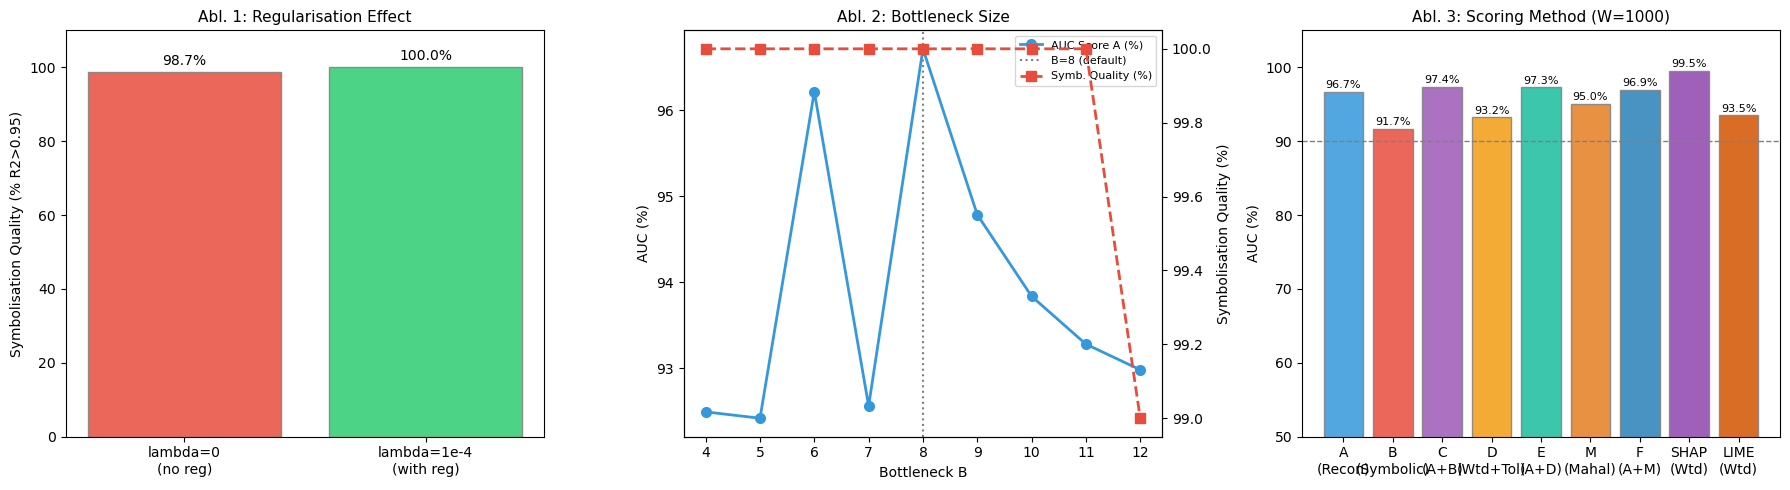

In [26]:
# Ablation 3 table
auc_shap_1000 = full_bench.loc["SHAP-Weighted-Recon", 1000]
auc_lime_1000 = full_bench.loc["LIME-Weighted-Recon", 1000]

abl3_df = pd.DataFrame({
    "Method":        ["Score A (Recon)", "Score B (Symbolic)", "Score C (A+B)",
                      "Score D (Wtd+Tol)", "Score E (A+D)",
                      "Score M (Mahalanobis)", "Score F (A+M)",
                      "SHAP-Weighted-Recon", "LIME-Weighted-Recon"],
    "AUC W=1000":    [round(auc_A,4), round(auc_B,4), round(auc_C,4),
                      round(auc_D,4), round(auc_E,4),
                      round(auc_M,4), round(auc_F,4),
                      round(auc_shap_1000,4), round(auc_lime_1000,4)],
    "Interpretable": ["No", "Yes", "Partial", "Yes", "Partial", "Yes", "Partial",
                      "Global (SHAP)", "Global (LIME)"],
})
print("Ablation 3: Scoring Method Comparison")
display(abl3_df)

# 3-panel ablation figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: regularisation
ax = axes[0]
ax.bar(["lambda=0\n(no reg)", "lambda=1e-4\n(with reg)"],
       [qual_noreg, qual], color=["#e74c3c","#2ecc71"], alpha=0.85, edgecolor="grey")
ax.set_ylabel("Symbolisation Quality (% R2>0.95)", fontsize=10)
ax.set_title("Abl. 1: Regularisation Effect", fontsize=11)
ax.set_ylim(0, 110)
for i, v in enumerate([qual_noreg, qual]):
    ax.text(i, v+2, f"{v:.1f}%", ha="center", fontsize=10)

# Panel 2: bottleneck size (dual y-axis)
ax  = axes[1]
ax2 = ax.twinx()
ax.plot(ablation_b_df.index, ablation_b_df["AUC_scoreA"]*100,
        "o-", color="#3498db", label="AUC Score A (%)", linewidth=2, markersize=7)
ax2.plot(ablation_b_df.index, ablation_b_df["symb_quality_%"],
         "s--", color="#e74c3c", label="Symb. Quality (%)", linewidth=2, markersize=7)
ax.axvline(B, color="gray", linestyle=":", linewidth=1.5, label=f"B={B} (default)")
ax.set_xlabel("Bottleneck B", fontsize=10); ax.set_ylabel("AUC (%)", fontsize=10)
ax2.set_ylabel("Symbolisation Quality (%)", fontsize=10)
ax.set_title("Abl. 2: Bottleneck Size", fontsize=11)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=8)

# Panel 3: all 9 scoring methods (7 KAN-AE + SHAP + LIME)
ax = axes[2]
score_labels = ["A\n(Recon)", "B\n(Symbolic)", "C\n(A+B)", "D\n(Wtd+Tol)", "E\n(A+D)",
                "M\n(Mahal)", "F\n(A+M)", "SHAP\n(Wtd)", "LIME\n(Wtd)"]
score_aucs   = [auc_A*100, auc_B*100, auc_C*100, auc_D*100, auc_E*100,
                auc_M*100, auc_F*100, auc_shap_1000*100, auc_lime_1000*100]
colors_p3    = ["#3498db", "#e74c3c", "#9b59b6", "#f39c12", "#1abc9c",
                "#e67e22", "#2980b9", "#8e44ad", "#d35400"]
bars = ax.bar(score_labels, score_aucs, color=colors_p3, alpha=0.85, edgecolor="grey")
ax.set_ylabel("AUC (%)", fontsize=10)
ax.set_title("Abl. 3: Scoring Method (W=1000)", fontsize=11)
ax.set_ylim(50, 105)
ax.axhline(90, color="gray", linestyle="--", linewidth=1)
for bar, v in zip(bars, score_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, v+0.5, f"{v:.1f}%",
            ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "ablation_summary.svg"))
plt.show()

# Save combined ablation table
abl_rows = (
    [{"ablation":"Reg",       "variant":"lambda=0",  "metric":"symb_quality_%", "value":qual_noreg},
     {"ablation":"Reg",       "variant":"lambda=1e-4","metric":"symb_quality_%", "value":qual}] +
    [{"ablation":"Bottleneck","variant":f"B={b}",     "metric":"AUC_scoreA",     "value":ablation_b_df.loc[b,"AUC_scoreA"]}
     for b in B_values] +
    [{"ablation":"Scoring",   "variant":"ScoreA",     "metric":"AUC_W1000",      "value":auc_A},
     {"ablation":"Scoring",   "variant":"ScoreB",     "metric":"AUC_W1000",      "value":auc_B},
     {"ablation":"Scoring",   "variant":"ScoreC",     "metric":"AUC_W1000",      "value":auc_C},
     {"ablation":"Scoring",   "variant":"ScoreD",     "metric":"AUC_W1000",      "value":auc_D},
     {"ablation":"Scoring",   "variant":"ScoreE",     "metric":"AUC_W1000",      "value":auc_E},
     {"ablation":"Scoring",   "variant":"ScoreM",     "metric":"AUC_W1000",      "value":auc_M},
     {"ablation":"Scoring",   "variant":"ScoreF",     "metric":"AUC_W1000",      "value":auc_F},
     {"ablation":"Scoring",   "variant":"SHAP-Wtd",   "metric":"AUC_W1000",      "value":auc_shap_1000},
     {"ablation":"Scoring",   "variant":"LIME-Wtd",   "metric":"AUC_W1000",      "value":auc_lime_1000}]
)
pd.DataFrame(abl_rows).to_csv(os.path.join(RESULTS_DIR, "ablation_table.csv"), index=False)


## Consolidated Summary & Conclusions

In [27]:
print("=" * 72)
print("  KAN SYMBOLIC HEALTH EQUATION DISCOVERY — CONSOLIDATED SUMMARY")
print("=" * 72)

print(f"\n1. Model: KAN-AE [44->22->{B}->22->44]  lambda={LAMBDA_REG}  epochs={EPOCHS}")
print(f"   Final training MSE: {losses[-1]:.6f}")

print(f"\n2. Edge Pruning  (alpha={PRUNE_ALPHA}):")
print(f"   Surviving edges: {n_surviving}/{n_total}  ({100*n_surviving/n_total:.1f}%)")

print(f"\n3. Symbolic Regression:")
print(f"   Symbolisation quality (R2>0.95): {qual:.1f}%")
print(f"   Mean R2: {sym_df['r2'].mean():.4f}")
print(f"   Symbol distribution:")
for sym, cnt in sym_df['best_symbol'].value_counts().items():
    print(f"     {sym:12s}: {cnt}")

print(f"\n4. Anomaly Detection  (W=1000):")
print(f"   Score A (Reconstruction):         AUC = {auc_A:.4f}")
print(f"   Score B (Symbolic):               AUC = {auc_B:.4f}")
print(f"   Score C (Combined A+B):           AUC = {auc_C:.4f}")
print(f"   Score D (Weighted+Tolerance):     AUC = {auc_D:.4f}  [pct-band: 5th-95th]")
print(f"   Score E (Combined A+D):           AUC = {auc_E:.4f}")
print(f"   Score M (Mahalanobis):            AUC = {auc_M:.4f}")
print(f"   Score F (Combined A+M):           AUC = {auc_F:.4f}")

print(f"\n5. Sample Health Equations (first 5 neurons):")
for j in range(min(5, 22)):
    print(f"   {health_equations[j]}")

auc_shap_1000 = full_bench.loc["SHAP-Weighted-Recon", 1000]
auc_lime_1000 = full_bench.loc["LIME-Weighted-Recon", 1000]
print(f"\n6. Benchmark position (W=1000, 18 methods total):")
all_w1000    = full_bench[1000].sort_values(ascending=False)
rank_c       = list(all_w1000.index).index("KAN-AE-Combined") + 1
rank_e       = list(all_w1000.index).index("KAN-AE-Combined-E") + 1
rank_f       = list(all_w1000.index).index("KAN-AE-Combined-F") + 1
rank_shap    = list(all_w1000.index).index("SHAP-Weighted-Recon") + 1
rank_lime    = list(all_w1000.index).index("LIME-Weighted-Recon") + 1
print(f"   KAN-AE-Combined   ranks #{rank_c} of {len(all_w1000)}")
print(f"   KAN-AE-Combined-E ranks #{rank_e} of {len(all_w1000)}")
print(f"   KAN-AE-Combined-F ranks #{rank_f} of {len(all_w1000)}")
print(f"   SHAP-Weighted-Recon ranks #{rank_shap} of {len(all_w1000)}  (AUC={auc_shap_1000*100:.2f}%)")
print(f"   LIME-Weighted-Recon ranks #{rank_lime} of {len(all_w1000)}  (AUC={auc_lime_1000*100:.2f}%)")
print(f"   Best overall: {all_w1000.index[0]} = {all_w1000.iloc[0]*100:.2f}%")

print(f"\n7. Fault localisation top-3 most violated equations:")
for eq_idx in top_violated[:3]:
    feats = sym_df[sym_df['out_neuron']==eq_idx]['in_feature'].tolist()
    sensors = sorted(set(f.split('_')[0] for f in feats))
    print(f"   z_{eq_idx:02d}: fault_ratio={fault_ratio[eq_idx]:.2f}x  sensors={sensors}")

print(f"\n8. Ablation highlights:")
print(f"   Reg: lambda=0 quality={qual_noreg:.1f}%  vs  lambda=1e-4 quality={qual:.1f}%")
best_b = ablation_b_df['AUC_scoreA'].idxmax()
print(f"   Best bottleneck: B={best_b}  AUC={ablation_b_df.loc[best_b,'AUC_scoreA']:.4f}")

print(f"\n9. All outputs saved to: {RESULTS_DIR}/")
import os as _os
for f in sorted(_os.listdir(RESULTS_DIR)):
    print(f"   {f}")
print("=" * 72)


  KAN SYMBOLIC HEALTH EQUATION DISCOVERY — CONSOLIDATED SUMMARY

1. Model: KAN-AE [44->22->8->22->44]  lambda=0.0001  epochs=150
   Final training MSE: 0.007439

2. Edge Pruning  (alpha=0.05):
   Surviving edges: 839/968  (86.7%)

3. Symbolic Regression:
   Symbolisation quality (R2>0.95): 100.0%
   Mean R2: 0.9999
   Symbol distribution:
     quadratic   : 824
     sin         : 11
     hinge       : 2
     sigmoid     : 1
     tanh        : 1

4. Anomaly Detection  (W=1000):
   Score A (Reconstruction):         AUC = 0.9671
   Score B (Symbolic):               AUC = 0.9171
   Score C (Combined A+B):           AUC = 0.9739
   Score D (Weighted+Tolerance):     AUC = 0.9323  [pct-band: 5th-95th]
   Score E (Combined A+D):           AUC = 0.9729
   Score M (Mahalanobis):            AUC = 0.9501
   Score F (Combined A+M):           AUC = 0.9692

5. Sample Health Equations (first 5 neurons):
   z_00  ≈  +0.045*S1_rms^2 +0.107*S1_rms -0.000  +  +0.010*S1_std^2 +0.024*S1_std -0.000  +  +0.05